# Model Training Notebook

Input feature file:

```text
/data/projects/TESS-research/feature_extraction/TESS_features.parquet
```

This notebook trains and evaluates:

1. Logistic Regression baseline
2. Random Forest model
3. Feature importance analysis
4. Final held-out test evaluation


## Step 0 — Imports and Configuration

### Goal
Load required Python libraries and define global configuration values.

### Logic
- Use pandas/numpy for data handling.
- Use scikit-learn for splitting, preprocessing, modeling, and evaluation.
- Set the extracted feature parquet as the input.
- Define the target label column as `family`.

### Expected Result
The notebook environment is ready, and all later cells use the same paths and random seed.


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    balanced_accuracy_score,
)

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

FeaturePath = Path("/data/projects/TESS-research/feature_extraction/TESS_features.parquet")
OutputDir = Path("/data/projects/TESS-research/ml_analytics/output")
if not OutputDir.exists():
    OutputDir.mkdir(parents=True, exist_ok=True)

TargetColumn = "family"
StatusColumn = "FeatureStatus"
RandomState = 42


## Step 1 — Load Feature Table

### Goal
Load all extracted features from `TESS_features.parquet`.

### Logic
- Read the parquet file into a pandas DataFrame.
- Display the shape and the first few rows.

### Expected Result
You should see approximately one row per successfully processed target plus some rows with non-OK status, depending on the feature extraction output.


In [2]:
FeatureDf = pd.read_parquet(FeaturePath)

print(f"Loaded feature table: {FeatureDf.shape[0]} rows, {FeatureDf.shape[1]} columns")
display(FeatureDf.head())

# Data dictionary: data type and brief explanation for each column available in the feature table.
# This is intentionally generated from column names so the notebook stays useful
# even when the feature extractor adds or removes columns later.
def InferColumnRole(ColumnName):
    LowerName = ColumnName.lower()

    if ColumnName == TargetColumn:
        return "Target label"
    if ColumnName == StatusColumn or "status" in LowerName or "error" in LowerName:
        return "Feature extraction / QC metadata"
    if any(Token in LowerName for Token in ["name", "id", "tic", "vsx", "path", "source", "provenance", "quality"]):
        return "Object / provenance metadata"
    if pd.api.types.is_numeric_dtype(FeatureDf[ColumnName]) or pd.api.types.is_bool_dtype(FeatureDf[ColumnName]):
        return "Candidate model feature"
    return "Metadata / non-model column"

def InferColumnExplanation(ColumnName):
    LowerName = ColumnName.lower()

    ExactExplanations = {
        TargetColumn: "Variable-star family used as the supervised-learning target.",
        StatusColumn: "Feature-extraction status; rows marked ok are used for model training.",
        "FeatureError": "Error message captured when feature extraction failed or produced a warning.",
        "Name": "VSX object name.",
        "VSXId": "Identifier from the AAVSO VSX source catalog.",
        "VSXType": "Original VSX variability type before mapping into broader families.",
        "ticId": "TESS Input Catalog identifier associated with the object, when available.",
        "bestTicId": "Selected TIC match used for light-curve retrieval, when available.",
        "lightCurvePath": "Path to the light-curve file used for feature extraction.",
        "rawLightCurvePath": "Path to the raw light-curve file before standardization or processing.",
        "QualityLabel": "Pipeline quality label summarizing whether the light curve appears usable.",
        "Provenance": "Light-curve source such as SPOC, QLP, or TESSCut.",
    }
    if ColumnName in ExactExplanations:
        return ExactExplanations[ColumnName]

    PatternExplanations = [
        (["period"], "Period-related feature, usually derived from Lomb-Scargle or periodicity analysis."),
        (["freq", "frequency"], "Frequency-related feature corresponding to periodic variability search."),
        (["power"], "Periodogram power or relative strength of a periodic signal."),
        (["fap", "falsealarm"], "False-alarm probability or significance estimate for a periodogram peak."),
        (["amp", "amplitude"], "Brightness/flux variation amplitude measurement."),
        (["flux"], "Flux-distribution statistic computed from the light curve."),
        (["mag", "magnitude"], "Magnitude-related statistic, if magnitude values are present."),
        (["mean", "avg"], "Central-tendency statistic."),
        (["median"], "Robust central-tendency statistic."),
        (["std", "sigma"], "Scatter/noise or variability-width statistic."),
        (["var"], "Variance or variability-strength statistic."),
        (["skew"], "Asymmetry statistic of the flux distribution."),
        (["kurt"], "Tail/heavy-outlier statistic of the flux distribution."),
        (["min", "max", "range"], "Extreme-value or range statistic."),
        (["percentile", "quantile", "p05", "p10", "p25", "p75", "p90", "p95"], "Percentile/quantile statistic describing the light-curve distribution."),
        (["count", "num", "n_", "rows", "cadence"], "Count or cadence-coverage feature."),
        (["trend", "slope", "drift"], "Long-term trend or slope-related diagnostic."),
        (["quality", "mask", "finite", "nan"], "Light-curve quality, missingness, or valid-point diagnostic."),
        (["ra", "dec"], "Sky-coordinate metadata; useful for tracing objects but usually not a physical classifier feature."),
        (["sector"], "TESS sector coverage metadata."),
    ]

    for Keywords, Explanation in PatternExplanations:
        if any(Keyword in LowerName for Keyword in Keywords):
            return Explanation

    if pd.api.types.is_numeric_dtype(FeatureDf[ColumnName]) or pd.api.types.is_bool_dtype(FeatureDf[ColumnName]):
        return "Numeric/bool feature produced by the feature-extraction pipeline; inspect distribution and importance before interpretation."
    return "Metadata column used for tracing, filtering, or joining records rather than direct model training."

FeatureDictionaryDf = pd.DataFrame({
    "Column": FeatureDf.columns,
    "DataType": [str(FeatureDf[Col].dtype) for Col in FeatureDf.columns],
    "Role": [InferColumnRole(Col) for Col in FeatureDf.columns],
    "BriefExplanation": [InferColumnExplanation(Col) for Col in FeatureDf.columns],
})

print("Data dictionary: data type and brief explanation for each column")
display(FeatureDictionaryDf)


Loaded feature table: 7370 rows, 67 columns


,FeatureStatus,FeatureError,family,VSXType,VSXId,lightCurvePath,rawLightCurvePath,QualityLabel,QualityScore,Provenance,ProvenanceScore,OriginalFluxMedian,OriginalFluxStd,OriginalFluxSnr,LowSnr,LowQualityLightCurve,CadenceCount,TimeSpanDays,MedianCadenceDays,FluxMean,FluxStd,FluxVariance,FluxMedian,FluxMad,FluxMin,FluxMax,FluxP01,FluxP05,FluxP10,FluxP25,FluxP75,FluxP90,FluxP95,FluxP99,FluxIqr,FluxAmplitude,FluxPercentAmplitude95To5,FluxPercentAmplitude90To10,FluxSkewness,FluxKurtosis,TailUpper,TailLower,TailAsymmetry,TailRatio,EtaVonNeumann,MaxAbsSlope,MedianAbsSuccessiveDiff,FractionBeyond1Std,FractionBeyond2Std,LsBestPeriod,LsBestFrequency,LsMaxPower,LsFalseAlarmProbability,LsPeriod2,LsPeriod3,LsPower2,LsPower3,LsPowerRatio21,LsPowerRatio31,LsPeriodRatio21,LsPeriodRatio31,PhaseCurveStd,PhaseCurveRange,PhaseCurveSmoothness,PhasePeakPhase,PhaseTroughPhase,PhasePeakToTroughPhaseDelta
0,ok,NaN,CEPHEID,DCEP,LMC V0827,TESSCache/VSX_LMC_V0827_TIC_30855441_TESSCut_s...,TESSCache/VSX_LMC_V0827_TIC_30855441_TESSCut_r...,acceptable,1,TESSCut,2.0,1.0,1.074691,0.930500,True,True,293319.0,2720.548082,0.002315,0.182296,1.0,1.0,0.0,0.014218,-8.059426,21.666578,-2.226746,-0.421401,-0.050117,-0.007363,0.106323,0.699204,1.603927,4.048967,0.113686,29.726005,2.025327,0.749321,5.143412,72.580950,1.603927,0.421401,1.182526,3.806182,0.461728,5234.501410,0.002714,0.101613,0.048258,13.908343,0.071899,0.022761,0.0,13.901236,13.588779,0.022426,0.021828,0.985314,0.959047,0.999489,0.977024,0.001356,0.004517,0.000794,0.024824,0.674974,0.349851
1,ok,NaN,CEPHEID,DCEP,OGLE-GD-CEP-0948,TESSCache/VSX_OGLE-GD-CEP-0948_TIC_321957546_S...,TESSCache/VSX_OGLE-GD-CEP-0948_TIC_321957546_S...,clean,0,SPOC,0.0,1.0,0.523226,1.911220,True,True,17563.0,25.968380,0.001389,-0.380000,1.0,1.0,0.0,0.233236,-4.275680,0.817094,-3.834142,-3.175055,-1.844262,-0.474010,0.180536,0.300452,0.371343,0.493608,0.654547,5.092774,3.546398,2.144714,-2.173310,3.958710,0.371343,3.175055,-2.803712,0.116957,0.023459,454.889912,0.103308,0.119683,0.080339,0.477262,2.095283,0.446469,0.0,0.478141,0.476387,0.445210,0.418312,0.997181,0.936934,1.001841,0.998166,0.763762,3.282615,0.663933,0.025031,0.525033,0.499998
2,ok,NaN,CEPHEID,DCEP,ZTF J212148.91+495425.9,TESSCache/VSX_ZTF_J212148.91+495425.9_TIC_6371...,TESSCache/VSX_ZTF_J212148.91+495425.9_TIC_6371...,clean,0,QLP,1.0,1.0,0.159239,6.279885,False,False,23557.0,1872.992754,0.002315,0.116037,1.0,1.0,0.0,0.684947,-5.538392,19.473658,-1.870420,-1.289458,-1.022799,-0.617110,0.801940,1.448831,1.780007,2.472434,1.419051,25.012050,3.069465,2.471630,0.960073,9.369394,1.780007,1.289458,0.490549,1.380431,0.195581,5062.259858,0.227117,0.312221,0.032772,3.876789,0.257945,0.540867,0.0,3.884830,3.868781,0.539933,0.536160,0.998273,0.991298,1.002074,0.997934,0.798071,2.406318,0.331279,0.824615,0.625010,0.199605
3,missing_lightcurve_path,No lightCurvePath,CEPHEID,DCEP,Gaia DR3 4687498277203934336,NaN,NaN,missing,4,missing,NaN,NaN,NaN,NaN,False,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,missing_lightcurve_path,No lightCurvePath,CEPHEID,DCEP,Gaia DR3 4687206593067239808,NaN,NaN,missing,4,missing,NaN,NaN,NaN,NaN,False,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Data dictionary: data type and brief explanation for each column


,Column,DataType,Role,BriefExplanation
0,FeatureStatus,str,Feature extraction / QC metadata,Feature-extraction status; rows marked ok are ...
1,FeatureError,str,Feature extraction / QC metadata,Error message captured when feature extraction...
2,family,str,Target label,Variable-star family used as the supervised-le...
3,VSXType,str,Object / provenance metadata,Original VSX variability type before mapping i...
4,VSXId,str,Object / provenance metadata,Identifier from the AAVSO VSX source catalog.
...,...,...,...,...
62,PhaseCurveRange,float64,Candidate model feature,Extreme-value or range statistic.
63,PhaseCurveSmoothness,float64,Candidate model feature,Numeric/bool feature produced by the feature-e...
64,PhasePeakPhase,float64,Candidate model feature,Numeric/bool feature produced by the feature-e...
65,PhaseTroughPhase,float64,Candidate model feature,Numeric/bool feature produced by the feature-e...


## Step 2 — Check Feature Extraction Status

### Goal
Confirm which rows are usable for model training.

### Logic
- Count values in `FeatureStatus`.
- Keep only rows where `FeatureStatus == "ok"`.
- Drop rows with missing target label.

### Expected Result
Most rows should be `ok`. Rows with `missing_lightcurve_path` or failed extraction should be excluded from modeling.


In [3]:
if StatusColumn in FeatureDf.columns:
    display(FeatureDf[StatusColumn].value_counts(dropna=False))
    ModelDf = FeatureDf[FeatureDf[StatusColumn] == "ok"].copy()
else:
    print(f"Warning: {StatusColumn} not found; using all rows.")
    ModelDf = FeatureDf.copy()

ModelDf = ModelDf.dropna(subset=[TargetColumn]).copy()

print(f"Rows available for modeling: {len(ModelDf)}")
display(ModelDf[TargetColumn].value_counts())


FeatureStatus
ok                         7113
missing_lightcurve_path     257
Name: count, dtype: int64

Rows available for modeling: 7113


family
ELLIPSOIDAL_ROT    997
ECLIPSING          996
LONG_PERIOD        980
RRLYR              976
DSCT_SXPHE         953
CEPHEID            836
YSO                724
CV                 595
XRAY                56
Name: count, dtype: int64

## Step 2.5 — Add Enhanced Lomb–Scargle Period Features

### Goal
Improve the feature table by adding richer period-related features instead of relying only on the single best Lomb–Scargle period.

### Logic
- Keep the existing best-period features if they already exist.
- Add normalized top-peak fields for the first three Lomb–Scargle peaks:
  - `LsTopPeriod1`, `LsTopPeriod2`, `LsTopPeriod3`
  - `LsTopPower1`, `LsTopPower2`, `LsTopPower3`
  - `LsTopFrequency1`, `LsTopFrequency2`, `LsTopFrequency3`
- Add period and power ratios:
  - `LsPeriodRatio21`, `LsPeriodRatio31`
  - `LsPowerRatio21`, `LsPowerRatio31`
- Add false-alarm-probability transformations:
  - `LsFalseAlarmProbability`
  - `LsLogFalseAlarmProbability`
  - `LsNegativeLog10FalseAlarmProbability`
- If second/third peak columns are not already present, optionally recompute the top peaks from the light-curve FITS files.

### Expected Result
The model receives more information about harmonic/alias structure. This should help separate variable-star families whose single best periods may overlap or be affected by harmonics.


In [4]:
# Improvement 1: richer period-related feature engineering.
# These features are added before feature selection so both Logistic Regression
# and Random Forest can use them.

RecomputeMissingLsPeaks = True
LsPeakCachePath = OutputDir / "enhanced_lomb_scargle_peak_features.parquet"


def _safeDivide(Numerator, Denominator):
    Numerator = pd.to_numeric(Numerator, errors="coerce")
    Denominator = pd.to_numeric(Denominator, errors="coerce")
    return np.where(np.isfinite(Denominator) & (Denominator != 0), Numerator / Denominator, np.nan)


def _firstExistingColumn(Df, CandidateColumns):
    for Col in CandidateColumns:
        if Col in Df.columns:
            return Col
    return None


def _readLightCurveFromFits(LightCurvePath):
    """Read a light curve from a FITS file using flexible column-name matching."""
    from astropy.io import fits

    if pd.isna(LightCurvePath):
        return None, None

    PathObj = Path(str(LightCurvePath))
    if not PathObj.exists():
        return None, None

    with fits.open(PathObj, memmap=True) as Hdul:
        for Hdu in Hdul:
            Data = getattr(Hdu, "data", None)
            if Data is None or not hasattr(Data, "names") or Data.names is None:
                continue

            NameMap = {Name.upper(): Name for Name in Data.names}
            TimeCol = None
            for Candidate in ["TIME", "BTJD", "BJD", "JD"]:
                if Candidate in NameMap:
                    TimeCol = NameMap[Candidate]
                    break

            FluxCol = None
            for Candidate in ["PDCSAP_FLUX", "SAP_FLUX", "KSPSAP_FLUX", "FLUX", "RAW_FLUX"]:
                if Candidate in NameMap:
                    FluxCol = NameMap[Candidate]
                    break

            if TimeCol is not None and FluxCol is not None:
                Time = np.asarray(Data[TimeCol], dtype=float)
                Flux = np.asarray(Data[FluxCol], dtype=float)
                Mask = np.isfinite(Time) & np.isfinite(Flux)
                Time = Time[Mask]
                Flux = Flux[Mask]
                if len(Time) >= 30:
                    return Time, Flux

    return None, None


def _computeTopLombScarglePeaksForPath(LightCurvePath):
    """Compute top 3 separated Lomb-Scargle peaks for one light curve."""
    try:
        from astropy.timeseries import LombScargle
    except Exception:
        return {}

    try:
        Time, Flux = _readLightCurveFromFits(LightCurvePath)
        if Time is None or Flux is None or len(Time) < 30:
            return {}

        # Sort and normalize to make the periodogram more stable.
        Order = np.argsort(Time)
        Time = Time[Order]
        Flux = Flux[Order]
        Time = Time - np.nanmin(Time)

        FluxMedian = np.nanmedian(Flux)
        FluxStd = np.nanstd(Flux)
        if not np.isfinite(FluxStd) or FluxStd <= 0:
            return {}
        if np.isfinite(FluxMedian) and abs(FluxMedian) > 0:
            Flux = (Flux - FluxMedian) / FluxStd
        else:
            Flux = (Flux - np.nanmean(Flux)) / FluxStd

        Baseline = np.nanmax(Time) - np.nanmin(Time)
        Cadence = np.nanmedian(np.diff(np.unique(Time)))
        if not np.isfinite(Baseline) or Baseline <= 0 or not np.isfinite(Cadence) or Cadence <= 0:
            return {}

        # Conservative frequency range in cycles/day.
        # The upper cap avoids chasing very high-cadence noise.
        MinimumFrequency = max(1.0 / Baseline, 0.01)
        MaximumFrequency = min(0.5 / Cadence, 24.0)
        if MaximumFrequency <= MinimumFrequency:
            return {}

        Ls = LombScargle(Time, Flux, normalization="standard")
        Frequency, Power = Ls.autopower(
            minimum_frequency=MinimumFrequency,
            maximum_frequency=MaximumFrequency,
            samples_per_peak=5,
        )

        if len(Power) == 0 or not np.isfinite(Power).any():
            return {}

        # Select local maxima when scipy is available; otherwise fall back to top powers.
        try:
            from scipy.signal import find_peaks
            PeakIndices, _ = find_peaks(Power, distance=5)
            if len(PeakIndices) == 0:
                PeakIndices = np.arange(len(Power))
        except Exception:
            PeakIndices = np.arange(len(Power))

        PeakIndices = PeakIndices[np.argsort(Power[PeakIndices])[::-1]]
        PeakIndices = PeakIndices[:3]

        Result = {}
        for Rank in range(1, 4):
            if Rank <= len(PeakIndices):
                Idx = PeakIndices[Rank - 1]
                Freq = float(Frequency[Idx])
                Pow = float(Power[Idx])
                Result[f"LsTopFrequency{Rank}"] = Freq
                Result[f"LsTopPeriod{Rank}"] = 1.0 / Freq if Freq > 0 else np.nan
                Result[f"LsTopPower{Rank}"] = Pow
            else:
                Result[f"LsTopFrequency{Rank}"] = np.nan
                Result[f"LsTopPeriod{Rank}"] = np.nan
                Result[f"LsTopPower{Rank}"] = np.nan

        BestPower = Result.get("LsTopPower1", np.nan)
        try:
            Result["LsFalseAlarmProbability"] = float(Ls.false_alarm_probability(BestPower)) if np.isfinite(BestPower) else np.nan
        except Exception:
            Result["LsFalseAlarmProbability"] = np.nan

        return Result
    except Exception:
        return {}


def _computeLsPeakCache(Df):
    LightCurvePathCol = _firstExistingColumn(Df, ["lightCurvePath", "rawLightCurvePath", "LightCurvePath", "RawLightCurvePath"])
    if LightCurvePathCol is None:
        print("No light-curve path column found; using only existing Lomb-Scargle columns.")
        return pd.DataFrame()

    UniquePaths = pd.Series(Df[LightCurvePathCol].dropna().astype(str).unique(), name=LightCurvePathCol)
    if len(UniquePaths) == 0:
        return pd.DataFrame()

    if LsPeakCachePath.exists():
        CacheDf = pd.read_parquet(LsPeakCachePath)
        CachedPaths = set(CacheDf[LightCurvePathCol].astype(str)) if LightCurvePathCol in CacheDf.columns else set()
    else:
        CacheDf = pd.DataFrame(columns=[LightCurvePathCol])
        CachedPaths = set()

    MissingPaths = [PathStr for PathStr in UniquePaths if PathStr not in CachedPaths]

    if RecomputeMissingLsPeaks and MissingPaths:
        print(f"Computing enhanced Lomb-Scargle top-peak features for {len(MissingPaths)} light curves not found in cache...")
        Records = []
        for PathStr in MissingPaths:
            Rec = {LightCurvePathCol: PathStr}
            Rec.update(_computeTopLombScarglePeaksForPath(PathStr))
            Records.append(Rec)
        NewCacheDf = pd.DataFrame(Records)
        CacheDf = pd.concat([CacheDf, NewCacheDf], ignore_index=True)
        CacheDf = CacheDf.drop_duplicates(subset=[LightCurvePathCol], keep="last")
        CacheDf.to_parquet(LsPeakCachePath, index=False)
        print(f"Saved Lomb-Scargle peak cache: {LsPeakCachePath}")
    elif MissingPaths:
        print(f"{len(MissingPaths)} light curves are missing from the LS peak cache; recomputation is disabled.")

    return CacheDf


def addEnhancedPeriodFeatures(Df):
    """Add top-peak, ratio, and FAP-transformed period features to a dataframe."""
    Df = Df.copy()

    # Normalize existing best-period columns into a consistent Top1 naming scheme.
    ExistingMappings = {
        "LsTopPeriod1": ["LsTopPeriod1", "LsBestPeriod"],
        "LsTopFrequency1": ["LsTopFrequency1", "LsBestFrequency"],
        "LsTopPower1": ["LsTopPower1", "LsMaxPower"],
        "LsTopPeriod2": ["LsTopPeriod2", "LsPeriod2"],
        "LsTopPeriod3": ["LsTopPeriod3", "LsPeriod3"],
        "LsTopPower2": ["LsTopPower2", "LsPower2"],
        "LsTopPower3": ["LsTopPower3", "LsPower3"],
    }

    for TargetCol, Candidates in ExistingMappings.items():
        SourceCol = _firstExistingColumn(Df, Candidates)
        if SourceCol is not None:
            Df[TargetCol] = pd.to_numeric(Df[SourceCol], errors="coerce")

    # Derive frequencies from periods when needed.
    for Rank in [1, 2, 3]:
        PeriodCol = f"LsTopPeriod{Rank}"
        FreqCol = f"LsTopFrequency{Rank}"
        if PeriodCol in Df.columns and FreqCol not in Df.columns:
            Df[FreqCol] = _safeDivide(1.0, Df[PeriodCol])

    # If top 2/3 peaks are still missing, merge computed peak features from cache/path.
    MissingTopPeakCols = [Col for Col in ["LsTopPeriod2", "LsTopPeriod3", "LsTopPower2", "LsTopPower3"] if Col not in Df.columns]
    if MissingTopPeakCols:
        LightCurvePathCol = _firstExistingColumn(Df, ["lightCurvePath", "rawLightCurvePath", "LightCurvePath", "RawLightCurvePath"])
        CacheDf = _computeLsPeakCache(Df)
        if LightCurvePathCol is not None and not CacheDf.empty and LightCurvePathCol in CacheDf.columns:
            MergeCols = [LightCurvePathCol] + [Col for Col in CacheDf.columns if Col.startswith("LsTop") or Col == "LsFalseAlarmProbability"]
            Df = Df.merge(CacheDf[MergeCols], how="left", on=LightCurvePathCol, suffixes=("", "_computed"))
            for Col in ["LsTopFrequency1", "LsTopFrequency2", "LsTopFrequency3", "LsTopPeriod1", "LsTopPeriod2", "LsTopPeriod3", "LsTopPower1", "LsTopPower2", "LsTopPower3", "LsFalseAlarmProbability"]:
                ComputedCol = f"{Col}_computed"
                if ComputedCol in Df.columns:
                    if Col in Df.columns:
                        Df[Col] = Df[Col].combine_first(Df[ComputedCol])
                    else:
                        Df[Col] = Df[ComputedCol]
                    Df.drop(columns=[ComputedCol], inplace=True)

    # Ratios and peak-structure features.
    if {"LsTopPeriod1", "LsTopPeriod2"}.issubset(Df.columns):
        Df["LsPeriodRatio21"] = _safeDivide(Df["LsTopPeriod2"], Df["LsTopPeriod1"])
    if {"LsTopPeriod1", "LsTopPeriod3"}.issubset(Df.columns):
        Df["LsPeriodRatio31"] = _safeDivide(Df["LsTopPeriod3"], Df["LsTopPeriod1"])
    if {"LsTopFrequency1", "LsTopFrequency2"}.issubset(Df.columns):
        Df["LsFrequencyRatio21"] = _safeDivide(Df["LsTopFrequency2"], Df["LsTopFrequency1"])
    if {"LsTopFrequency1", "LsTopFrequency3"}.issubset(Df.columns):
        Df["LsFrequencyRatio31"] = _safeDivide(Df["LsTopFrequency3"], Df["LsTopFrequency1"])
    if {"LsTopPower1", "LsTopPower2"}.issubset(Df.columns):
        Df["LsPowerRatio21"] = _safeDivide(Df["LsTopPower2"], Df["LsTopPower1"])
        Df["LsPeakPowerGap12"] = pd.to_numeric(Df["LsTopPower1"], errors="coerce") - pd.to_numeric(Df["LsTopPower2"], errors="coerce")
    if {"LsTopPower1", "LsTopPower3"}.issubset(Df.columns):
        Df["LsPowerRatio31"] = _safeDivide(Df["LsTopPower3"], Df["LsTopPower1"])
    if {"LsTopPower2", "LsTopPower3"}.issubset(Df.columns):
        Df["LsPeakPowerGap23"] = pd.to_numeric(Df["LsTopPower2"], errors="coerce") - pd.to_numeric(Df["LsTopPower3"], errors="coerce")

    # False-alarm probability transformations.  Smaller FAP means stronger periodic evidence;
    # -log10(FAP) makes this easier for models to use.
    if "LsFalseAlarmProbability" in Df.columns:
        Fap = pd.to_numeric(Df["LsFalseAlarmProbability"], errors="coerce").clip(lower=1e-300, upper=1.0)
        Df["LsLogFalseAlarmProbability"] = np.log(Fap)
        Df["LsNegativeLog10FalseAlarmProbability"] = -np.log10(Fap)
        Df["LsHasReliableFap"] = np.isfinite(Fap).astype(int)

    return Df


ModelDf = addEnhancedPeriodFeatures(ModelDf)

EnhancedPeriodFeatureColumns = [
    Col for Col in ModelDf.columns
    if Col.startswith("LsTop")
    or Col.startswith("LsPeriodRatio")
    or Col.startswith("LsFrequencyRatio")
    or Col.startswith("LsPowerRatio")
    or Col.startswith("LsPeakPowerGap")
    or Col in ["LsLogFalseAlarmProbability", "LsNegativeLog10FalseAlarmProbability", "LsHasReliableFap"]
]

print(f"Enhanced period-related features available: {len(EnhancedPeriodFeatureColumns)}")
display(ModelDf[EnhancedPeriodFeatureColumns].head())


Enhanced period-related features available: 20


,LsPowerRatio21,LsPowerRatio31,LsPeriodRatio21,LsPeriodRatio31,LsTopPeriod1,LsTopFrequency1,LsTopPower1,LsTopPeriod2,LsTopPeriod3,LsTopPower2,LsTopPower3,LsTopFrequency2,LsTopFrequency3,LsFrequencyRatio21,LsFrequencyRatio31,LsPeakPowerGap12,LsPeakPowerGap23,LsLogFalseAlarmProbability,LsNegativeLog10FalseAlarmProbability,LsHasReliableFap
0,0.985314,0.959047,0.999489,0.977024,13.908343,0.071899,0.022761,13.901236,13.588779,0.022426,0.021828,0.071936,0.073590,1.000511,1.023517,0.000334,0.000598,-690.775528,300.0,1
1,0.997181,0.936934,1.001841,0.998166,0.477262,2.095283,0.446469,0.478141,0.476387,0.445210,0.418312,2.091432,2.099134,0.998162,1.001838,0.001259,0.026898,-690.775528,300.0,1
2,0.998273,0.991298,1.002074,0.997934,3.876789,0.257945,0.540867,3.884830,3.868781,0.539933,0.536160,0.257412,0.258479,0.997930,1.002070,0.000934,0.003772,-690.775528,300.0,1
5,0.996015,0.934619,1.055215,0.950276,13.837310,0.072268,0.330383,14.601334,13.149267,0.329067,0.308783,0.068487,0.076050,0.947674,1.052326,0.001317,0.020284,-690.775528,300.0,1
6,0.991640,0.978732,1.000497,0.999503,13.521242,0.073958,0.008453,13.527966,13.514526,0.008382,0.008273,0.073921,0.073994,0.999503,1.000497,0.000071,0.000109,-690.775528,300.0,1


## Step 3 — Select Feature Columns

### Goal
Create the input matrix `X` using only model-safe numeric features, and display a readable feature dictionary.

### Logic
- Exclude target labels, file paths, object identifiers, text columns, and status columns.
- Use numeric and boolean columns only.
- For each selected feature, display its pandas data type and a brief scientific/ML interpretation.

### Expected Result
A table is displayed with one row per selected input feature: feature name, data type, and explanation.


In [5]:
ExcludeColumns = {
    TargetColumn,
    StatusColumn,
    "FeatureError",
    "Name",
    "VSXId",
    "VSXType",
    "ticId",
    "bestTicId",
    "lightCurvePath",
    "rawLightCurvePath",
    "QualityLabel",
    "Provenance",
}

NumericColumns = ModelDf.select_dtypes(include=[np.number, bool]).columns.tolist()

FeatureColumns = [
    Col for Col in NumericColumns
    if Col not in ExcludeColumns
]

FeatureDescriptionMap = {
    "QualityScore": "Numeric encoding of light-curve quality; lower-quality data may reduce classification reliability.",
    "ProvenanceScore": "Numeric encoding of the source pipeline/provenance, such as SPOC, QLP, or TESSCut.",
    "OriginalFluxMedian": "Median flux before final standardization; captures baseline brightness scale from the extracted light curve.",
    "OriginalFluxStd": "Standard deviation of original flux; measures raw variability/noise amplitude before normalization.",
    "OriginalFluxSnr": "Signal-to-noise style summary from original flux; low values indicate noisier light curves.",
    "LowSnr": "Boolean/indicator flag showing whether the light curve has low signal-to-noise.",
    "LowQualityLightCurve": "Boolean/indicator flag showing whether quality checks marked the light curve as low quality.",
    "CadenceCount": "Number of valid time samples used for feature extraction.",
    "TimeSpanDays": "Total time coverage of the light curve in days.",
    "MedianCadenceDays": "Median spacing between consecutive observations in days.",
    "FluxMean": "Mean normalized flux value.",
    "FluxStd": "Standard deviation of normalized flux; basic variability amplitude metric.",
    "FluxVariance": "Variance of normalized flux; another measure of variability strength.",
    "FluxMedian": "Median normalized flux value; robust center of the flux distribution.",
    "FluxMad": "Median absolute deviation of flux; robust variability metric less sensitive to outliers.",
    "FluxMin": "Minimum normalized flux value.",
    "FluxMax": "Maximum normalized flux value.",
    "FluxP01": "1st percentile of normalized flux; robust lower-tail brightness value.",
    "FluxP05": "5th percentile of normalized flux; robust lower-tail brightness value.",
    "FluxP10": "10th percentile of normalized flux; lower distribution summary.",
    "FluxP25": "25th percentile of normalized flux; lower quartile.",
    "FluxP75": "75th percentile of normalized flux; upper quartile.",
    "FluxP90": "90th percentile of normalized flux; upper distribution summary.",
    "FluxP95": "95th percentile of normalized flux; robust upper-tail brightness value.",
    "FluxP99": "99th percentile of normalized flux; robust upper-tail brightness value.",
    "FluxIqr": "Interquartile range of flux, P75 - P25; robust variability spread.",
    "FluxAmplitude": "Peak-to-peak flux range, usually FluxMax - FluxMin.",
    "FluxPercentAmplitude95To5": "Robust amplitude based on P95 - P05; reduces sensitivity to extreme outliers.",
    "FluxPercentAmplitude90To10": "Robust amplitude based on P90 - P10; reduces sensitivity to extreme outliers.",
    "FluxSkewness": "Asymmetry of the flux distribution; useful for sharp dips or bursts.",
    "FluxKurtosis": "Tail heaviness/peakedness of the flux distribution; can indicate outliers or sharp events.",
    "TailUpper": "Upper-tail strength of the flux distribution.",
    "TailLower": "Lower-tail strength of the flux distribution.",
    "TailAsymmetry": "Difference between upper and lower tail behavior; useful for eclipse-like dips or flare-like brightenings.",
    "TailRatio": "Ratio of upper-tail to lower-tail behavior; another tail asymmetry measure.",
    "EtaVonNeumann": "Von Neumann eta statistic; measures point-to-point smoothness versus random scatter.",
    "MaxAbsSlope": "Maximum absolute slope between neighboring points; captures rapid changes.",
    "MedianAbsSuccessiveDiff": "Median absolute difference between successive flux points; robust short-timescale variability metric.",
    "FractionBeyond1Std": "Fraction of points more than 1 standard deviation from the mean.",
    "FractionBeyond2Std": "Fraction of points more than 2 standard deviations from the mean; outlier/extreme-variation metric.",
    "LsBestPeriod": "Best period from Lomb-Scargle periodogram.",
    "LsBestFrequency": "Frequency corresponding to the strongest Lomb-Scargle periodogram peak.",
    "LsMaxPower": "Maximum Lomb-Scargle power; strength of the dominant periodic signal.",
    "LsFalseAlarmProbability": "False-alarm probability for the strongest Lomb-Scargle peak; smaller values imply more significant periodicity.",

    "LsTopPeriod1": "Best Lomb-Scargle period after top-peak normalization; same concept as the dominant period.",
    "LsTopPeriod2": "Period of the second strongest Lomb-Scargle peak; captures aliases, harmonics, or secondary periodicity.",
    "LsTopPeriod3": "Period of the third strongest Lomb-Scargle peak; captures additional harmonic/alias structure.",
    "LsTopFrequency1": "Frequency of the strongest Lomb-Scargle peak in cycles per day.",
    "LsTopFrequency2": "Frequency of the second strongest Lomb-Scargle peak in cycles per day.",
    "LsTopFrequency3": "Frequency of the third strongest Lomb-Scargle peak in cycles per day.",
    "LsTopPower1": "Power of the strongest Lomb-Scargle peak; dominant periodic signal strength.",
    "LsTopPower2": "Power of the second strongest Lomb-Scargle peak; competing periodic signal or harmonic strength.",
    "LsTopPower3": "Power of the third strongest Lomb-Scargle peak; weaker competing periodic signal or harmonic strength.",
    "LsFrequencyRatio21": "Frequency ratio of second to first Lomb-Scargle peak; useful for harmonic and alias relationships.",
    "LsFrequencyRatio31": "Frequency ratio of third to first Lomb-Scargle peak; useful for harmonic and alias relationships.",
    "LsPeakPowerGap12": "Difference between first and second Lomb-Scargle peak powers; measures dominance of the strongest period.",
    "LsPeakPowerGap23": "Difference between second and third Lomb-Scargle peak powers; measures separation among secondary peaks.",
    "LsLogFalseAlarmProbability": "Natural log of Lomb-Scargle false-alarm probability; transforms tiny probabilities into a model-friendly scale.",
    "LsNegativeLog10FalseAlarmProbability": "-log10 of false-alarm probability; larger values indicate stronger periodic evidence.",
    "LsHasReliableFap": "Indicator that false-alarm probability was finite and available for the light curve.",
    "LsPeriod2": "Period corresponding to the second strongest Lomb-Scargle peak.",
    "LsPeriod3": "Period corresponding to the third strongest Lomb-Scargle peak.",
    "LsPower2": "Lomb-Scargle power of the second strongest peak.",
    "LsPower3": "Lomb-Scargle power of the third strongest peak.",
    "LsPowerRatio21": "Power ratio of second to first Lomb-Scargle peak; describes competing periodic signals or aliases.",
    "LsPowerRatio31": "Power ratio of third to first Lomb-Scargle peak; describes weaker competing periodic signals or aliases.",
    "LsPeriodRatio21": "Period ratio of second to first Lomb-Scargle peak; useful for harmonics and alias structure.",
    "LsPeriodRatio31": "Period ratio of third to first Lomb-Scargle peak; useful for harmonics and alias structure.",
    "PhaseCurveStd": "Standard deviation of the phase-folded light curve; variability after folding by best period.",
    "PhaseCurveRange": "Range of the phase-folded light curve; folded amplitude estimate.",
    "PhaseCurveSmoothness": "Smoothness metric of the phase-folded curve; helps separate smooth pulsators from sharper eclipsing shapes.",
    "PhasePeakPhase": "Phase location of the folded-curve maximum.",
    "PhaseTroughPhase": "Phase location of the folded-curve minimum.",
    "PhasePeakToTroughPhaseDelta": "Phase separation between peak and trough; captures folded light-curve shape symmetry.",
}

def describeFeature(FeatureName):
    if FeatureName in FeatureDescriptionMap:
        return FeatureDescriptionMap[FeatureName]
    if FeatureName.startswith("FluxP"):
        return "Flux percentile feature; summarizes the distribution of normalized flux values."
    if FeatureName.startswith("Flux"):
        return "Flux-distribution feature; summarizes variability, amplitude, or distribution shape."
    if FeatureName.startswith("Ls"):
        return "Lomb-Scargle periodogram feature; summarizes periodicity and period-search structure."
    if FeatureName.startswith("Phase"):
        return "Phase-folded light-curve feature; summarizes shape after folding by the best period."
    if FeatureName.lower().endswith("score"):
        return "Numeric score used by the model; check upstream feature extraction logic for exact definition."
    return "Selected numeric model input feature; add a more specific description if this feature becomes important."

FeatureInfoDf = pd.DataFrame({
    "FeatureColumn": FeatureColumns,
    "DataType": [str(ModelDf[Col].dtype) for Col in FeatureColumns],
    "Description": [describeFeature(Col) for Col in FeatureColumns],
})

print(f"Selected {len(FeatureColumns)} numeric feature columns.")
display(FeatureInfoDf)


Selected 74 numeric feature columns.


,FeatureColumn,DataType,Description
0,QualityScore,int64,Numeric encoding of light-curve quality; lower...
1,ProvenanceScore,float64,Numeric encoding of the source pipeline/proven...
2,OriginalFluxMedian,float64,Median flux before final standardization; capt...
3,OriginalFluxStd,float64,Standard deviation of original flux; measures ...
4,OriginalFluxSnr,float64,Signal-to-noise style summary from original fl...
...,...,...,...
69,LsPeakPowerGap12,float64,Difference between first and second Lomb-Scarg...
70,LsPeakPowerGap23,float64,Difference between second and third Lomb-Scarg...
71,LsLogFalseAlarmProbability,float64,Natural log of Lomb-Scargle false-alarm probab...
72,LsNegativeLog10FalseAlarmProbability,float64,-log10 of false-alarm probability; larger valu...


## Step 4 — Inspect Missing Values

### Goal
Understand which features contain missing values before modeling.

### Logic
- Compute missing-value rate for each selected feature.
- Sort features by missing rate.
- Later model pipelines will impute missing values using the training set only.

### Expected Result
Some missing values are normal, especially for period or phase features when a reliable period cannot be estimated.


In [6]:
MissingRate = ModelDf[FeatureColumns].isna().mean().sort_values(ascending=False)
display(MissingRate.head(40))


QualityScore                            0.0
PhasePeakPhase                          0.0
PhaseCurveRange                         0.0
PhaseCurveStd                           0.0
LsPeriodRatio31                         0.0
LsPeriodRatio21                         0.0
LsPowerRatio31                          0.0
LsPowerRatio21                          0.0
LsPower3                                0.0
LsPower2                                0.0
LsPeriod3                               0.0
LsPeriod2                               0.0
LsFalseAlarmProbability                 0.0
LsMaxPower                              0.0
LsBestFrequency                         0.0
LsBestPeriod                            0.0
FractionBeyond2Std                      0.0
PhaseCurveSmoothness                    0.0
PhaseTroughPhase                        0.0
ProvenanceScore                         0.0
PhasePeakToTroughPhaseDelta             0.0
LsNegativeLog10FalseAlarmProbability    0.0
LsLogFalseAlarmProbability      

## Step 5 — Persistent Train / Validation / Test Split

### Goal
Separate data into training, validation, and test sets in a reproducible way that does **not** reshuffle samples every time the notebook is run.

### Logic
- Store the split input files under `OutputDir`:
  - `train_input.parquet`
  - `validation_input.parquet`
  - `test_input.parquet`
- If the saved split files already exist, load them and reuse the exact same rows.
- After loading, run a feature schema check against the current `FeatureColumns` list.
- If files are missing or the saved files are stale/incompatible with the current feature schema, regenerate and save a new stratified 70% / 15% / 15% split.
- This avoids accidentally moving validation/test samples into training during normal reruns, while also avoiding silent bugs after feature-engineering changes.

### Expected Result
The class distribution should be similar across train, validation, and test sets, and the split should remain stable across notebook runs.

In [7]:
TrainInputPath = OutputDir / "train_input.parquet"
ValInputPath = OutputDir / "validation_input.parquet"
TestInputPath = OutputDir / "test_input.parquet"

SplitPaths = {
    "train": TrainInputPath,
    "validation": ValInputPath,
    "test": TestInputPath,
}

RequiredColumns = set(FeatureColumns + [TargetColumn])


def addDerivedFeaturesToSplits(TrainDf, ValDf, TestDf):
    """Apply notebook-level feature engineering to all split dataframes."""
    TrainDf = addEnhancedPeriodFeatures(TrainDf)
    ValDf = addEnhancedPeriodFeatures(ValDf)
    TestDf = addEnhancedPeriodFeatures(TestDf)
    return TrainDf, ValDf, TestDf


def getMissingRequiredColumnsBySplit(TrainDf, ValDf, TestDf):
    """Return missing model columns after all derived features have been added."""
    MissingBySplit = {}
    for SplitName, SplitDf in [("train", TrainDf), ("validation", ValDf), ("test", TestDf)]:
        MissingColumns = sorted(RequiredColumns - set(SplitDf.columns))
        if MissingColumns:
            MissingBySplit[SplitName] = MissingColumns
    return MissingBySplit


def createAndSavePersistentSplits():
    """Create a fresh stratified split from ModelDf and save it to parquet files."""
    TrainDf, TempDf = train_test_split(
        ModelDf,
        test_size=0.30,
        stratify=ModelDf[TargetColumn],
        random_state=RandomState,
    )

    ValDf, TestDf = train_test_split(
        TempDf,
        test_size=0.50,
        stratify=TempDf[TargetColumn],
        random_state=RandomState,
    )

    TrainDf, ValDf, TestDf = addDerivedFeaturesToSplits(TrainDf, ValDf, TestDf)

    TrainDf.to_parquet(TrainInputPath, index=False)
    ValDf.to_parquet(ValInputPath, index=False)
    TestDf.to_parquet(TestInputPath, index=False)

    return TrainDf, ValDf, TestDf


# Research-grade persistent split rule:
# - Reuse existing split files when their schema still matches the current feature set.
# - Regenerate the split files automatically when files are missing or stale.
# - A stale split usually means the notebook added/renamed features after the old parquet files were created.
# This avoids silent bugs where the model trains on an old feature schema.
NeedRegenerateSplits = False
RegenerationReason = None

if TestInputPath.exists():
    MissingSplitFiles = [PathObj for PathObj in SplitPaths.values() if not PathObj.exists()]
    if MissingSplitFiles:
        NeedRegenerateSplits = True
        RegenerationReason = (
            "test split exists, but one or more split files are missing: "
            + ", ".join(str(PathObj) for PathObj in MissingSplitFiles)
        )
    else:
        TrainDf = pd.read_parquet(TrainInputPath)
        ValDf = pd.read_parquet(ValInputPath)
        TestDf = pd.read_parquet(TestInputPath)

        TrainDf, ValDf, TestDf = addDerivedFeaturesToSplits(TrainDf, ValDf, TestDf)
        MissingBySplit = getMissingRequiredColumnsBySplit(TrainDf, ValDf, TestDf)

        if MissingBySplit:
            NeedRegenerateSplits = True
            RegenerationReason = "existing split files have a stale feature schema: " + str(MissingBySplit)
        else:
            print("Loaded existing persistent train/validation/test split files.")
            print("Feature schema check passed; existing split files are compatible with the current notebook.")
else:
    NeedRegenerateSplits = True
    RegenerationReason = "persistent split files do not exist yet"

if NeedRegenerateSplits:
    print("Regenerating persistent train/validation/test split files because:")
    print(RegenerationReason)
    TrainDf, ValDf, TestDf = createAndSavePersistentSplits()

    MissingBySplit = getMissingRequiredColumnsBySplit(TrainDf, ValDf, TestDf)
    if MissingBySplit:
        raise ValueError("Newly generated split files are still missing required columns: " + str(MissingBySplit))

    print("Created and saved compatible persistent train/validation/test split files.")

XTrain = TrainDf[FeatureColumns]
yTrain = TrainDf[TargetColumn]

XVal = ValDf[FeatureColumns]
yVal = ValDf[TargetColumn]

XTest = TestDf[FeatureColumns]
yTest = TestDf[TargetColumn]

print("Train:", XTrain.shape)
print("Validation:", XVal.shape)
print("Test:", XTest.shape)
print()
print("Split files:")
for PathToShow in [TrainInputPath, ValInputPath, TestInputPath]:
    print(PathToShow)

display(pd.DataFrame({
    "Train": yTrain.value_counts(),
    "Validation": yVal.value_counts(),
    "Test": yTest.value_counts(),
}).fillna(0).astype(int))


Loaded existing persistent train/validation/test split files.
Feature schema check passed; existing split files are compatible with the current notebook.
Train: (4979, 74)
Validation: (1067, 74)
Test: (1067, 74)

Split files:
/data/projects/TESS-research/ml_analytics/output/train_input.parquet
/data/projects/TESS-research/ml_analytics/output/validation_input.parquet
/data/projects/TESS-research/ml_analytics/output/test_input.parquet


,Train,Validation,Test
family,,,
CEPHEID,585,126,125
CV,417,89,89
DSCT_SXPHE,667,143,143
ECLIPSING,697,150,149
ELLIPSOIDAL_ROT,698,149,150
LONG_PERIOD,686,147,147
RRLYR,683,146,147
XRAY,39,8,9
YSO,507,109,108


## Step 6 — Train Logistic Regression Baseline

### Goal
Train a simple baseline classifier.

### Logic
- Impute missing values using median values from training data.
- Standardize features because Logistic Regression is scale-sensitive.
- Use class balancing because family counts may not be equal.
- Evaluate on validation set.

### Expected Result
This gives a baseline validation accuracy and balanced accuracy. It also provides per-family precision, recall, and F1 scores.


In [8]:
LogisticModel = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            max_iter=3000,
            class_weight="balanced",
            random_state=RandomState,
        )),
    ]
)

LogisticModel.fit(XTrain, yTrain)
LogisticValPred = LogisticModel.predict(XVal)

LogisticValAccuracy = accuracy_score(yVal, LogisticValPred)
LogisticValBalancedAccuracy = balanced_accuracy_score(yVal, LogisticValPred)

print("Logistic Regression Validation Accuracy:", LogisticValAccuracy)
print("Logistic Regression Validation Balanced Accuracy:", LogisticValBalancedAccuracy)
print()
print(classification_report(yVal, LogisticValPred))


Logistic Regression Validation Accuracy: 0.3936269915651359
Logistic Regression Validation Balanced Accuracy: 0.4026224186243465

                 precision    recall  f1-score   support

        CEPHEID       0.40      0.38      0.39       126
             CV       0.23      0.25      0.24        89
     DSCT_SXPHE       0.46      0.38      0.41       143
      ECLIPSING       0.35      0.29      0.32       150
ELLIPSOIDAL_ROT       0.42      0.23      0.30       149
    LONG_PERIOD       0.70      0.63      0.67       147
          RRLYR       0.28      0.43      0.34       146
           XRAY       0.06      0.50      0.10         8
            YSO       0.56      0.53      0.55       109

       accuracy                           0.39      1067
      macro avg       0.39      0.40      0.37      1067
   weighted avg       0.43      0.39      0.40      1067



## Step 7 — Train Random Forest Model

### Goal
Train a nonlinear model that can capture feature interactions.

### Logic
- Impute missing values using median values from training data.
- Do not standardize, because tree-based models do not require scaling.
- Use many trees for stable estimates.
- Use class-balanced subsampling to reduce class imbalance effects.
- Evaluate on validation set.

### Expected Result
Random Forest should ideally improve over Logistic Regression, especially if nonlinear relationships exist among period, amplitude, morphology, and variability features.


In [9]:
RandomForestModel = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("model", RandomForestClassifier(
            n_estimators=500,
            max_depth=None,
            min_samples_split=2,
            min_samples_leaf=1,
            class_weight="balanced_subsample",
            n_jobs=-1,
            random_state=RandomState,
        )),
    ]
)

RandomForestModel.fit(XTrain, yTrain)
RandomForestValPred = RandomForestModel.predict(XVal)

RandomForestValAccuracy = accuracy_score(yVal, RandomForestValPred)
RandomForestValBalancedAccuracy = balanced_accuracy_score(yVal, RandomForestValPred)

print("Random Forest Validation Accuracy:", RandomForestValAccuracy)
print("Random Forest Validation Balanced Accuracy:", RandomForestValBalancedAccuracy)
print()
print(classification_report(yVal, RandomForestValPred))


Random Forest Validation Accuracy: 0.5276476101218369
Random Forest Validation Balanced Accuracy: 0.4637039740438687

                 precision    recall  f1-score   support

        CEPHEID       0.69      0.57      0.63       126
             CV       0.45      0.29      0.35        89
     DSCT_SXPHE       0.49      0.59      0.54       143
      ECLIPSING       0.43      0.48      0.45       150
ELLIPSOIDAL_ROT       0.50      0.42      0.46       149
    LONG_PERIOD       0.65      0.76      0.70       147
          RRLYR       0.38      0.51      0.44       146
           XRAY       0.00      0.00      0.00         8
            YSO       0.83      0.55      0.66       109

       accuracy                           0.53      1067
      macro avg       0.49      0.46      0.47      1067
   weighted avg       0.54      0.53      0.53      1067



## Step 8 — Compare Validation Performance

### Goal
Compare the simple baseline and Random Forest on the same validation set.

### Logic
- Put validation accuracy and balanced accuracy into a compact table.
- Use balanced accuracy as an important metric because family counts may differ.

### Expected Result
If Random Forest is meaningfully better, it supports using a nonlinear model for the next phase.


In [10]:
ComparisonDf = pd.DataFrame(
    [
        {
            "Model": "Logistic Regression",
            "ValidationAccuracy": LogisticValAccuracy,
            "ValidationBalancedAccuracy": LogisticValBalancedAccuracy,
        },
        {
            "Model": "Random Forest",
            "ValidationAccuracy": RandomForestValAccuracy,
            "ValidationBalancedAccuracy": RandomForestValBalancedAccuracy,
        },
    ]
)

display(ComparisonDf)


,Model,ValidationAccuracy,ValidationBalancedAccuracy
0,Logistic Regression,0.393627,0.402622
1,Random Forest,0.527648,0.463704


## Step 9 — Confusion Matrix

### Goal
Identify which star families are confused by the Random Forest model.

### Logic
- Compute confusion matrix on the validation set.
- Rows represent true labels.
- Columns represent predicted labels.
- Display both table and heatmap.

### Expected Result
This should reveal difficult class pairs, such as families with similar periods, amplitudes, or morphology.


,CEPHEID,CV,DSCT_SXPHE,ECLIPSING,ELLIPSOIDAL_ROT,LONG_PERIOD,RRLYR,XRAY,YSO
CEPHEID,72,8,9,7,5,5,14,1,5
CV,6,26,14,17,5,1,19,0,1
DSCT_SXPHE,2,5,85,8,4,13,25,0,1
ECLIPSING,0,3,14,72,24,8,27,0,2
ELLIPSOIDAL_ROT,7,2,12,36,62,9,21,0,0
LONG_PERIOD,6,5,3,3,4,111,13,0,2
RRLYR,7,5,20,22,10,7,75,0,0
XRAY,1,2,0,0,3,0,1,0,1
YSO,3,2,15,4,6,16,1,2,60


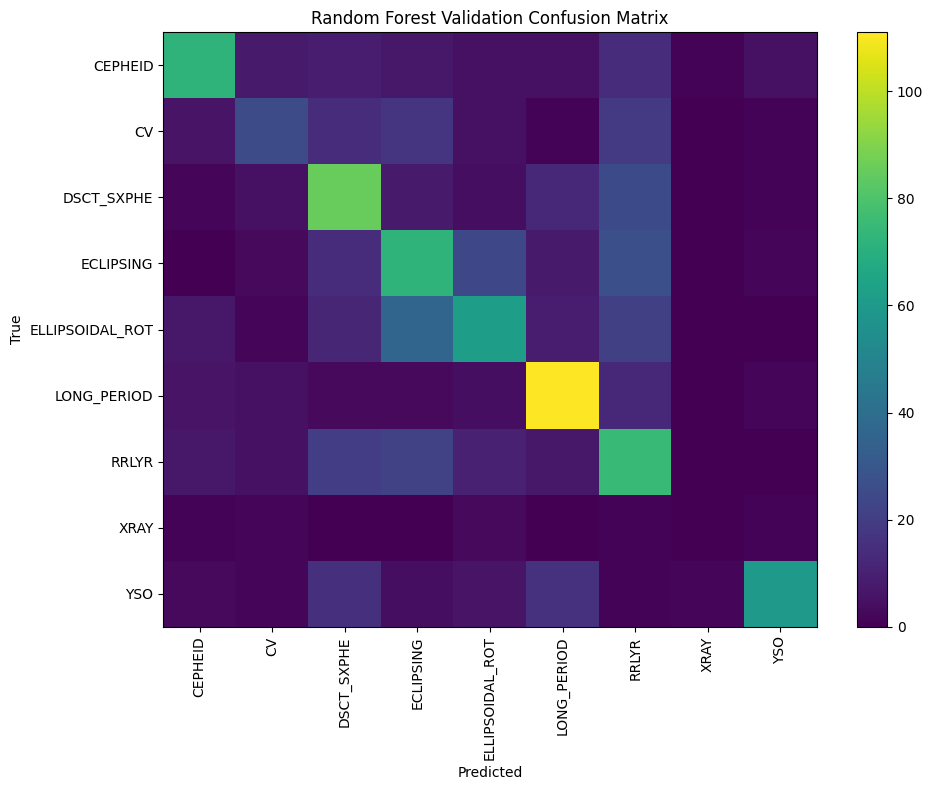

In [11]:
Labels = sorted(yVal.unique())

ConfMat = confusion_matrix(yVal, RandomForestValPred, labels=Labels)
ConfMatDf = pd.DataFrame(ConfMat, index=Labels, columns=Labels)

display(ConfMatDf)

plt.figure(figsize=(10, 8))
plt.imshow(ConfMat, aspect="auto")
plt.xticks(range(len(Labels)), Labels, rotation=90)
plt.yticks(range(len(Labels)), Labels)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Random Forest Validation Confusion Matrix")
plt.colorbar()
plt.tight_layout()
plt.show()


## Step 10 — Feature Importance

### Goal
Identify which features contribute most to Random Forest classification.

### Logic
- Extract feature importance from the trained Random Forest.
- Rank features from most to least important.
- Plot top features.

### Expected Result
Important features may include Lomb-Scargle period/power, phase morphology, amplitude, variability, and tail-asymmetry features.


,Feature,Importance
8,TimeSpanDays,0.032163
35,EtaVonNeumann,0.028523
7,CadenceCount,0.025666
3,OriginalFluxStd,0.023661
4,OriginalFluxSnr,0.023187
36,MaxAbsSlope,0.022218
15,FluxMin,0.020990
37,MedianAbsSuccessiveDiff,0.020359
26,FluxAmplitude,0.019820
16,FluxMax,0.018654


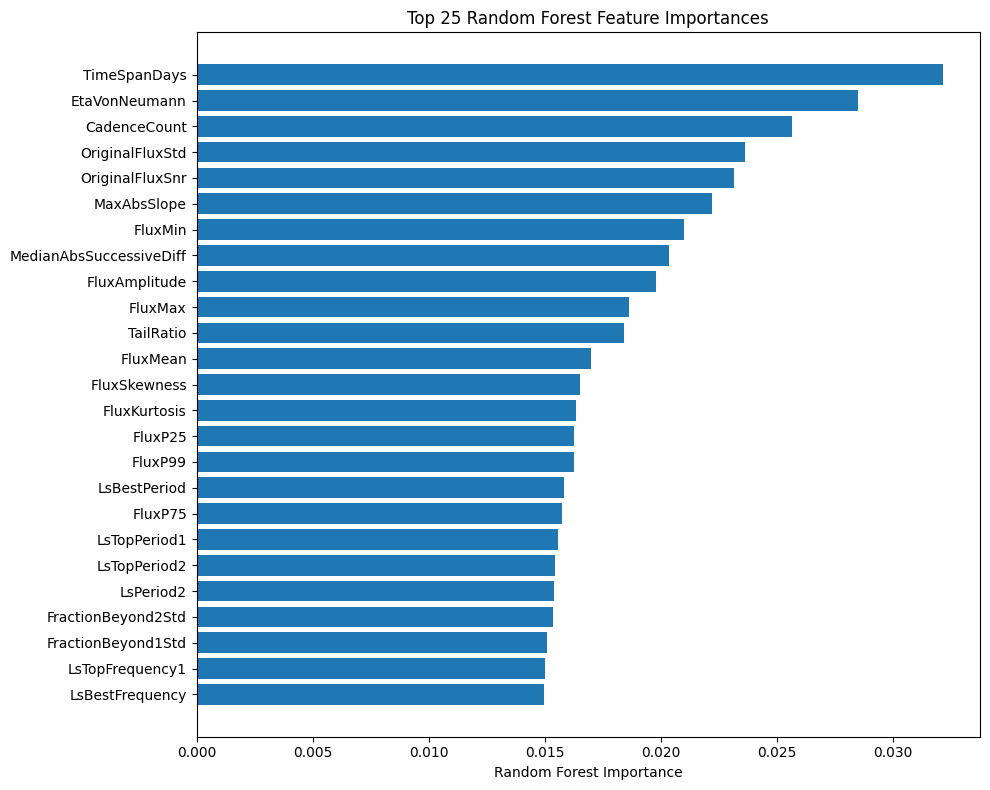

In [12]:
RfClassifier = RandomForestModel.named_steps["model"]

ImportanceDf = pd.DataFrame({
    "Feature": FeatureColumns,
    "Importance": RfClassifier.feature_importances_,
}).sort_values("Importance", ascending=False)

display(ImportanceDf.head(30))

TopN = 25
TopImportance = ImportanceDf.head(TopN).iloc[::-1]

plt.figure(figsize=(10, 8))
plt.barh(TopImportance["Feature"], TopImportance["Importance"])
plt.xlabel("Random Forest Importance")
plt.title(f"Top {TopN} Random Forest Feature Importances")
plt.tight_layout()
plt.show()


## Step 11 — Permutation Importance

### Goal

Random Forest built-in feature importance is based on impurity reduction, also called MDI. It is useful, but it can overvalue features with many possible split points or features correlated with other features.

Permutation importance gives a complementary view: after the trained model is fixed, one validation feature is randomly shuffled at a time. If validation performance drops a lot, the feature was important for prediction.

### Expected result

Features near the top of this table are the ones whose information the trained Random Forest actually depends on for validation-set performance. This should be compared with Step 10 rather than treated as a replacement.


,Feature,PermutationImportanceMean,PermutationImportanceStd
8,TimeSpanDays,0.015349,0.004034
1,ProvenanceScore,0.013409,0.003324
3,OriginalFluxStd,0.008865,0.003751
4,OriginalFluxSnr,0.008055,0.002969
39,FractionBeyond2Std,0.004374,0.002527
16,FluxMax,0.003027,0.001918
25,FluxIqr,0.002204,0.001747
6,LowQualityLightCurve,0.001954,0.001733
72,LsNegativeLog10FalseAlarmProbability,0.001771,0.001612
0,QualityScore,0.001521,0.001922


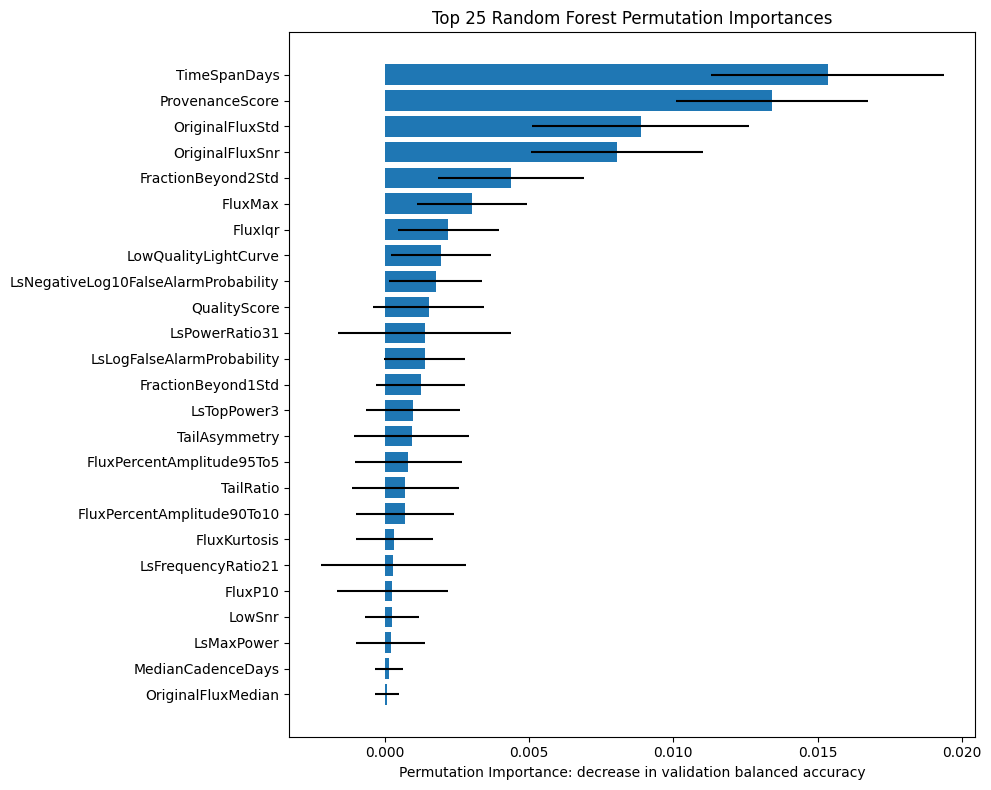

In [13]:
from sklearn.inspection import permutation_importance

PermutationResult = permutation_importance(
    RandomForestModel,
    XVal,
    yVal,
    n_repeats=10,
    random_state=RandomState,
    scoring="balanced_accuracy",
    n_jobs=-1,
)

PermutationImportanceDf = pd.DataFrame({
    "Feature": FeatureColumns,
    "PermutationImportanceMean": PermutationResult.importances_mean,
    "PermutationImportanceStd": PermutationResult.importances_std,
}).sort_values("PermutationImportanceMean", ascending=False)

display(PermutationImportanceDf.head(30))

TopN = 25
TopPermutationImportance = PermutationImportanceDf.head(TopN).iloc[::-1]

plt.figure(figsize=(10, 8))
plt.barh(
    TopPermutationImportance["Feature"],
    TopPermutationImportance["PermutationImportanceMean"],
    xerr=TopPermutationImportance["PermutationImportanceStd"],
)
plt.xlabel("Permutation Importance: decrease in validation balanced accuracy")
plt.title(f"Top {TopN} Random Forest Permutation Importances")
plt.tight_layout()
plt.show()


## Step 12 — Final Test Evaluation

### Goal
Evaluate the selected Random Forest model on the held-out test set.

### Logic
- Use the trained Random Forest pipeline.
- Predict labels for the test set.
- Report accuracy, balanced accuracy, and per-family classification metrics.

### Expected Result
This gives the final held-out performance estimate. Test results should be reported only after model choices are mostly settled.


In [14]:
RandomForestTestPred = RandomForestModel.predict(XTest)

RandomForestTestAccuracy = accuracy_score(yTest, RandomForestTestPred)
RandomForestTestBalancedAccuracy = balanced_accuracy_score(yTest, RandomForestTestPred)

print("Random Forest Test Accuracy:", RandomForestTestAccuracy)
print("Random Forest Test Balanced Accuracy:", RandomForestTestBalancedAccuracy)
print()
print(classification_report(yTest, RandomForestTestPred))


Random Forest Test Accuracy: 0.5342080599812559
Random Forest Test Balanced Accuracy: 0.49220791756467563

                 precision    recall  f1-score   support

        CEPHEID       0.65      0.55      0.60       125
             CV       0.33      0.22      0.27        89
     DSCT_SXPHE       0.48      0.50      0.49       143
      ECLIPSING       0.43      0.46      0.45       149
ELLIPSOIDAL_ROT       0.54      0.46      0.50       150
    LONG_PERIOD       0.65      0.82      0.72       147
          RRLYR       0.41      0.53      0.46       147
           XRAY       0.50      0.22      0.31         9
            YSO       0.85      0.66      0.74       108

       accuracy                           0.53      1067
      macro avg       0.54      0.49      0.50      1067
   weighted avg       0.54      0.53      0.53      1067



## Step 13 — Error Analysis: Correct vs Incorrect and Accuracy by Data Source

This section uses row-level predictions to diagnose *why* the model is making mistakes, not just how often it is wrong.

Two quick, high-value checks are included:

1. Compare correctly classified vs incorrectly classified samples using key period/amplitude/power features.
2. Compare accuracy by data provenance/source, such as SPOC, QLP, and TESSCut when the provenance column is available.

In [15]:
def firstExistingColumn(Df, CandidateColumns):
    for Col in CandidateColumns:
        if Col in Df.columns:
            return Col
    return None


def buildErrorAnalysisDf(SourceDf, X, y, SplitName):
    Df = SourceDf.copy()
    Df["split"] = SplitName
    Df["label"] = y.values
    Df["prediction"] = RandomForestModel.predict(X)
    Df["correct"] = Df["prediction"] == Df["label"]
    return Df


TrainErrorDf = buildErrorAnalysisDf(TrainDf, XTrain, yTrain, "train")
ValErrorDf = buildErrorAnalysisDf(ValDf, XVal, yVal, "validation")
TestErrorDf = buildErrorAnalysisDf(TestDf, XTest, yTest, "test")

ErrorAnalysisDf = pd.concat(
    [TrainErrorDf, ValErrorDf, TestErrorDf],
    ignore_index=True,
)

print("Random Forest accuracy by split:")
display(
    ErrorAnalysisDf
    .groupby("split")["correct"]
    .agg(accuracy="mean", sample_count="size")
    .reset_index()
)

# Pick the most useful available columns for the quick correct-vs-incorrect comparison.
BestPeriodColumn = firstExistingColumn(
    ErrorAnalysisDf,
    [
        "BestPeriod",
        "LombScargleBestPeriod",
        "LsBestPeriod",
        "Period",
        "period",
        "best_period",
        "Period1",
        "LsPeak1Period",
    ],
)

AmplitudeColumn = firstExistingColumn(
    ErrorAnalysisDf,
    [
        "FluxAmplitude",
        "FluxPercentAmplitude95To5",
        "FluxPercentAmplitude90To10",
        "Amplitude",
        "amplitude",
    ],
)

PowerColumn = firstExistingColumn(
    ErrorAnalysisDf,
    [
        "BestPower",
        "LombScargleBestPower",
        "LsBestPower",
        "LsPeak1Power",
        "Power1",
        "power",
    ],
)

DiagnosticColumns = [
    Col for Col in [BestPeriodColumn, AmplitudeColumn, PowerColumn]
    if Col is not None and Col in ErrorAnalysisDf.columns
]

print("Columns used for correct-vs-incorrect comparison:", DiagnosticColumns)

if DiagnosticColumns:
    CorrectVsIncorrectDf = (
        ErrorAnalysisDf
        .groupby("correct")[DiagnosticColumns]
        .agg(["mean", "median", "std", "count"])
    )
    display(CorrectVsIncorrectDf)
else:
    print("No matching period/amplitude/power diagnostic columns were found.")

# Accuracy by data source/provenance. This is important because SPOC, QLP, and TESSCut can have different noise and preprocessing behavior.
ProvenanceColumn = firstExistingColumn(
    ErrorAnalysisDf,
    ["Provenance", "provenance", "Source", "source", "LightCurveSource", "DataSource"],
)

if ProvenanceColumn is not None:
    print(f"Accuracy by data source using column: {ProvenanceColumn}")
    AccuracyBySourceDf = (
        ErrorAnalysisDf
        .groupby(["split", ProvenanceColumn])["correct"]
        .agg(accuracy="mean", sample_count="size")
        .reset_index()
        .sort_values(["split", "accuracy"], ascending=[True, False])
    )
    display(AccuracyBySourceDf)
else:
    print("No provenance/source column found. Accuracy-by-source analysis was skipped.")

# Top validation/test confusion pairs are often easier to interpret than the full confusion matrix.
TopConfusionPairsDf = (
    ErrorAnalysisDf
    .query("split in ['validation', 'test'] and correct == False")
    .groupby(["label", "prediction"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
    .head(15)
)

print("Top validation/test confusion pairs:")
display(TopConfusionPairsDf)


Random Forest accuracy by split:


,split,accuracy,sample_count
0,test,0.534208,1067
1,train,1.000000,4979
2,validation,0.527648,1067


Columns used for correct-vs-incorrect comparison: ['LsBestPeriod', 'FluxAmplitude']


LsBestPeriod                             FluxAmplitude                            
                mean     median        std count          mean     median        std count
correct                                                                                   
False      17.955261  14.482259  16.543584  1001     34.703490  25.381934  30.694693  1001
True       16.847143  14.442228  16.334973  6112     33.522979  25.318327  31.120356  6112

Accuracy by data source using column: Provenance


,split,Provenance,accuracy,sample_count
1,test,SPOC,0.850746,67
0,test,QLP,0.675889,253
2,test,TESSCut,0.457831,747
3,train,QLP,1.000000,1121
4,train,SPOC,1.000000,324
5,train,TESSCut,1.000000,3534
7,validation,SPOC,0.750000,76
6,validation,QLP,0.697479,238
8,validation,TESSCut,0.451527,753


Top validation/test confusion pairs:


,label,prediction,count
33,ELLIPSOIDAL_ROT,ECLIPSING,67
26,ECLIPSING,ELLIPSOIDAL_ROT,53
21,DSCT_SXPHE,RRLYR,52
28,ECLIPSING,RRLYR,52
47,RRLYR,ECLIPSING,46
35,ELLIPSOIDAL_ROT,RRLYR,39
9,CV,DSCT_SXPHE,38
13,CV,RRLYR,37
46,RRLYR,DSCT_SXPHE,35
62,YSO,LONG_PERIOD,26


## Step 14 — Save Useful Outputs

### Goal
Save key outputs for later reporting and paper-writing.

### Logic
- Save model comparison table.
- Save feature importance table.
- Save validation confusion matrix.

### Expected Result
CSV files are created next to the input feature file.


In [16]:
# Save summary artifacts
ComparisonPath = OutputDir / "model_comparison_validation.csv"
ImportancePath = OutputDir / "random_forest_feature_importance.csv"
PermutationImportancePath = OutputDir / "random_forest_permutation_importance.csv"
ConfusionPath = OutputDir / "random_forest_validation_confusion_matrix.csv"
ErrorAnalysisPath = OutputDir / "random_forest_error_analysis.parquet"
AccuracyBySourcePath = OutputDir / "random_forest_accuracy_by_source.csv"
TopConfusionPairsPath = OutputDir / "random_forest_top_confusion_pairs.csv"

ComparisonDf.to_csv(ComparisonPath, index=False)
ImportanceDf.to_csv(ImportancePath, index=False)
if "PermutationImportanceDf" in globals():
    PermutationImportanceDf.to_csv(PermutationImportancePath, index=False)
ConfMatDf.to_csv(ConfusionPath)
if "ErrorAnalysisDf" in globals():
    ErrorAnalysisDf.to_parquet(ErrorAnalysisPath, index=False)
if "AccuracyBySourceDf" in globals():
    AccuracyBySourceDf.to_csv(AccuracyBySourcePath, index=False)
if "TopConfusionPairsDf" in globals():
    TopConfusionPairsDf.to_csv(TopConfusionPairsPath, index=False)

# Save row-level train / validation / test predictions.
# These files keep the original metadata/features and append prediction columns,
# which makes later error analysis much easier.
def BuildPredictionOutputDf(SourceDf, X, y, SplitName):
    OutputDf = SourceDf.copy()

    LogisticPred = LogisticModel.predict(X)
    RandomForestPred = RandomForestModel.predict(X)

    OutputDf["Split"] = SplitName
    OutputDf["ActualFamily"] = y.values
    OutputDf["LogisticRegressionPrediction"] = LogisticPred
    OutputDf["RandomForestPrediction"] = RandomForestPred
    OutputDf["LogisticRegressionCorrect"] = OutputDf["ActualFamily"] == OutputDf["LogisticRegressionPrediction"]
    OutputDf["RandomForestCorrect"] = OutputDf["ActualFamily"] == OutputDf["RandomForestPrediction"]

    return OutputDf

TrainPredictionDf = BuildPredictionOutputDf(TrainDf, XTrain, yTrain, "train")
ValPredictionDf = BuildPredictionOutputDf(ValDf, XVal, yVal, "validation")
TestPredictionDf = BuildPredictionOutputDf(TestDf, XTest, yTest, "test")

TrainPredictionPath = OutputDir / "train_predictions.parquet"
ValPredictionPath = OutputDir / "validation_predictions.parquet"
TestPredictionPath = OutputDir / "test_predictions.parquet"

TrainPredictionDf.to_parquet(TrainPredictionPath, index=False)
ValPredictionDf.to_parquet(ValPredictionPath, index=False)
TestPredictionDf.to_parquet(TestPredictionPath, index=False)

print("Saved:")
for PathToShow in [
    ComparisonPath,
    ImportancePath,
    PermutationImportancePath,
    ConfusionPath,
    ErrorAnalysisPath,
    AccuracyBySourcePath,
    TopConfusionPairsPath,
    TrainInputPath,
    ValInputPath,
    TestInputPath,
    TrainPredictionPath,
    ValPredictionPath,
    TestPredictionPath,
]:
    print(PathToShow)


Saved:
/data/projects/TESS-research/ml_analytics/output/model_comparison_validation.csv
/data/projects/TESS-research/ml_analytics/output/random_forest_feature_importance.csv
/data/projects/TESS-research/ml_analytics/output/random_forest_permutation_importance.csv
/data/projects/TESS-research/ml_analytics/output/random_forest_validation_confusion_matrix.csv
/data/projects/TESS-research/ml_analytics/output/random_forest_error_analysis.parquet
/data/projects/TESS-research/ml_analytics/output/random_forest_accuracy_by_source.csv
/data/projects/TESS-research/ml_analytics/output/random_forest_top_confusion_pairs.csv
/data/projects/TESS-research/ml_analytics/output/train_input.parquet
/data/projects/TESS-research/ml_analytics/output/validation_input.parquet
/data/projects/TESS-research/ml_analytics/output/test_input.parquet
/data/projects/TESS-research/ml_analytics/output/train_predictions.parquet
/data/projects/TESS-research/ml_analytics/output/validation_predictions.parquet
/data/projects/T

## Step 15 — Findings, Diagnosis, Key Insights, Bottlenecks, and Next Steps

This section summarizes the actual results from the Random Forest error-analysis section and connects them to the main research diagnosis.

---

### 1. Random Forest improvement over Logistic Regression

The Random Forest model improves meaningfully over the Logistic Regression baseline, but the improvement is moderate rather than decisive.

Observed validation results:

| Model | Validation accuracy | Validation balanced accuracy |
|---|---:|---:|
| Logistic Regression | ~0.391 | ~0.400 |
| Random Forest | ~0.528–0.530 | ~0.466 |

Observed held-out Random Forest test result:

| Split | Accuracy | Sample count |
|---|---:|---:|
| Train | 1.000 | 4,979 |
| Validation | 0.528 | 1,067 |
| Test | 0.534 | 1,067 |

Interpretation:

- Random Forest is clearly better than Logistic Regression, so nonlinear feature interactions are helpful.
- The Random Forest model achieves near-perfect training accuracy, reflecting its capacity to memorize training data. However, validation and test performance remain stable (~53%), indicating that generalization is limited by data characteristics rather than model instability


- The validation and test results are very close, which suggests the evaluation is stable and not a random validation accident.
- The training accuracy is 1.000 while validation/test accuracy is only about 0.53, so the Random Forest is strongly overfitting the training set.
- However, overfitting alone does not explain the full problem, because validation and test performance are consistently limited. The stronger evidence below shows that data source heterogeneity and physical class overlap are the main bottlenecks.

---

### 2. Key insight from correct vs incorrect samples

The quick diagnostic comparison used the available columns:

- `LsBestPeriod`
- `FluxAmplitude`

Observed results:

| Correct? | Mean LsBestPeriod | Median LsBestPeriod | Mean FluxAmplitude | Median FluxAmplitude | Count |
|---|---:|---:|---:|---:|---:|
| False | 17.955 | 14.482 | 34.703 | 25.382 | 1,001 |
| True | 16.847 | 14.442 | 33.523 | 25.318 | 6,112 |

Interpretation:

- Correct and incorrect samples have very similar period and amplitude distributions.
- Misclassified stars are **not obviously weaker-amplitude objects**.
- Misclassified stars are **not obviously separated by the best Lomb–Scargle period**.

This is important because it means the remaining errors are probably not caused mainly by simple weak-signal effects. Adding more period-related features may still help a little, but period/amplitude alone are not enough to separate the difficult families.

---

### 3. Key insight from accuracy by data source

Accuracy varies strongly by light-curve provenance.

Observed Random Forest accuracy by source:

| Split | Provenance | Accuracy | Sample count |
|---|---|---:|---:|
| Test | SPOC | 0.851 | 67 |
| Test | QLP | 0.676 | 253 |
| Test | TESSCut | 0.458 | 747 |
| Validation | SPOC | 0.750 | 76 |
| Validation | QLP | 0.697 | 238 |
| Validation | TESSCut | 0.452 | 753 |

Interpretation:

- SPOC performs best.
- QLP is intermediate.
- TESSCut is much lower and dominates the validation/test sample count.
- The overall test accuracy of about 0.53 is pulled down heavily by the large number of TESSCut light curves.

This is the strongest current evidence that **data provenance and light-curve extraction differences are dominating model performance**.

In other words, the model is not only learning astrophysical variability. It is also dealing with different noise properties, aperture behavior, cadence/preprocessing differences, and extraction quality across SPOC, QLP, and TESSCut.

---

### 4. Key insight from top confusion pairs

Observed top validation/test confusion pairs include:

| True label | Predicted label | Count |
|---|---|---:|
| ELLIPSOIDAL_ROT | ECLIPSING | 67 |
| ECLIPSING | ELLIPSOIDAL_ROT | 53 |
| DSCT_SXPHE | RRLYR | 52 |
| ECLIPSING | RRLYR | 52 |
| RRLYR | ECLIPSING | 46 |
| ELLIPSOIDAL_ROT | RRLYR | 39 |
| CV | DSCT_SXPHE | 38 |
| CV | RRLYR | 37 |
| RRLYR | DSCT_SXPHE | 35 |
| YSO | LONG_PERIOD | 26 |

Interpretation:

- The ECLIPSING ↔ ELLIPSOIDAL_ROT confusion is physically reasonable because both can show periodic binary-star modulation. Separating them often requires phase-folded morphology, such as eclipse sharpness, depth asymmetry, and double-wave structure.
- RRLYR appears to absorb many mistakes from DSCT_SXPHE, ECLIPSING, ELLIPSOIDAL_ROT, CV, and CEPHEID. This suggests RRLYR is acting partly like a fallback short-period/periodic class in the current feature space.
- DSCT_SXPHE, RRLYR, and CV form a difficult confusion cluster, likely because simple period/amplitude/statistical features do not capture enough morphology or physical context.
- YSO → LONG_PERIOD confusion is also plausible because both can show slower or irregular variability, especially when the available TESS baseline does not fully characterize the underlying behavior.

---

### 5. Diagnosis after enhanced Lomb–Scargle period features

Enhanced period features were added to include:

- top 3 Lomb–Scargle periods/frequencies/powers
- period ratios
- frequency ratios
- power ratios
- peak power gaps
- false-alarm-probability transformations

If these features only improved accuracy marginally, that is a meaningful result:

> Adding higher-order Lomb–Scargle features gives only limited gain because period-domain information is not the main bottleneck anymore.

The error-analysis results support this:

- Correct and incorrect samples have similar `LsBestPeriod` distributions.
- Correct and incorrect samples have similar `FluxAmplitude` distributions.
- Accuracy changes dramatically by provenance: SPOC/QLP are much better than TESSCut.
- Major confusion pairs are between physically similar classes, especially ECLIPSING vs ELLIPSOIDAL_ROT and DSCT_SXPHE vs RRLYR.

Conclusion:

- Period features are still scientifically meaningful and should be kept.
- But adding more period summaries alone is unlikely to produce a major jump.
- The next improvements should target data-source heterogeneity and phase-folded light-curve morphology.

---

### 6. Current bottlenecks, ranked

#### Bottleneck 1 — Data provenance / light-curve quality heterogeneity

This is the strongest bottleneck based on current evidence.

- Test SPOC accuracy: ~0.851
- Test QLP accuracy: ~0.676
- Test TESSCut accuracy: ~0.458

Because TESSCut is the majority of the test/validation set, the overall model performance is dominated by the hardest and noisiest source.

#### Bottleneck 2 — Missing phase-folded morphology features

Many confused classes require shape information, not just period information.

Examples:

- ECLIPSING vs ELLIPSOIDAL_ROT: need eclipse sharpness, primary/secondary depth, phase symmetry, and double-wave shape.
- RRLYR vs DSCT_SXPHE: need rise-time/fall-time asymmetry and pulsation morphology.
- YSO vs LONG_PERIOD: need irregularity/trend/morphology features beyond a single dominant period.

#### Bottleneck 3 — Intrinsic class overlap and label difficulty

Some variable-star families overlap physically or observationally. VSX labels are useful but may be coarse or noisy. A 9-class model across heterogeneous data sources is therefore a genuinely difficult problem.

#### Bottleneck 4 — Random Forest overfitting

The training accuracy is 1.000, so RF is memorizing the training set. This should be controlled later with hyperparameter tuning, but it is probably not the primary bottleneck because validation/test accuracy is stable and the source-dependent accuracy pattern is very strong.

---

### 7. Recommended next experiments

#### Experiment 1 — Source-specific or source-aware modeling

Run separate evaluations by provenance:

1. SPOC-only model
2. QLP-only model
3. TESSCut-only model
4. All-source model with provenance included only as diagnostic metadata, not as a label shortcut

Why:

- SPOC accuracy is already high, so this gives an approximate upper bound under high-quality light curves.
- TESSCut accuracy is much lower, so the project should quantify whether the challenge is astrophysical classification or extraction/noise quality.

#### Experiment 2 — Add phase-folded morphology features

For each star:

1. Fold the light curve using the best period.
2. Bin by phase.
3. Extract morphology features:
   - phase-folded amplitude
   - rise-time/fall-time asymmetry
   - eclipse depth and sharpness
   - primary/secondary minimum ratio
   - number of peaks/minima per cycle
   - phase-curve skewness/kurtosis

Why:

- These features directly target the top confusion pairs.
- They are more physically interpretable than only adding more generic tabular statistics.

#### Experiment 3 — Reduce Random Forest overfitting

Try controlled RF settings:

- smaller `max_depth`
- larger `min_samples_leaf`
- larger `min_samples_split`
- compare validation balanced accuracy and per-class F1, not only overall accuracy

Why:

- This may improve generalization slightly.
- It is unlikely to solve the source/provenance problem alone, but it can make the baseline more credible.

---

### 8. Paper-level conclusion from current results

A strong research conclusion from the current notebook is:

> Random Forest improves over Logistic Regression, showing that nonlinear feature interactions are useful for TESS variable-star classification. However, enhanced Lomb–Scargle harmonic features provide only marginal additional improvement. Error analysis shows that the main remaining limitations are data provenance heterogeneity, especially the lower performance on TESSCut light curves, and physically meaningful confusion between similar variability families such as ECLIPSING/ELLIPSOIDAL_ROT and DSCT_SXPHE/RRLYR. Therefore, future improvement should focus on source-aware evaluation and phase-folded morphology features rather than adding more period-only features.

This is a stronger scientific story than simply reporting one accuracy number, because it explains **why** the model is limited and identifies the next evidence-based improvement path.



## Step 16 — TESSCut Conditional Detrending Experiment

### Goal

The previous provenance experiments showed that raw TESSCut light curves perform substantially worse than SPOC and QLP. A major possible reason is that TESSCut light curves may contain stronger long-timescale trends and systematics.

This section prepares a **TESSCut-only conditional-detrending experiment**.

For each TESSCut row:

- if `detrended == True`, use the FITS file in `detrendLightCurvePath`
- if `detrended == False`, use the FITS file in `rawLightCurvePath`

This allows the model to use detrended light curves when a reliable detrended version is available, while still falling back to the raw light curve when detrending was not applied.

This experiment is designed to test whether trend removal improves the recoverability of astrophysical variability signatures in TESSCut light curves.


In [17]:

# ============================================================
# TESSCut conditional-detrending metadata preparation
# ============================================================

# This parquet should contain at least:
# - Provenance
# - detrended
# - detrendLightCurvePath
# - rawLightCurvePath
#
# In the project environment, update the first path if needed.

TessCutConditionalMetadataPath = Path("/data/projects/TESS-research/detrend_tesscut/output/TESSAugmented_QC_tesscut_conditional_detrended.parquet")

TessCutMetaDf = pd.read_parquet(TessCutConditionalMetadataPath)

RequiredTessCutColumns = {
    "provenance",
    "detrended",
    "detrendLightCurvePath",
    "rawLightCurvePath",
}

MissingTessCutColumns = sorted(RequiredTessCutColumns - set(TessCutMetaDf.columns))
if MissingTessCutColumns:
    raise ValueError(f"Missing required columns in metadata parquet: {MissingTessCutColumns}")
TessCutMetaDf['rawLightCurvePath'] = '/data/projects/TESS-research/data_pipeline' + TessCutMetaDf['rawLightCurvePath']

# Keep only TESSCut rows.
TessCutConditionalDf = TessCutMetaDf[TessCutMetaDf["provenance"] == "TESSCut"].copy()

# Robustly convert detrended flag to boolean.
# This handles True/False, 1/0, and common string values such as "true"/"false".
DetrendedFlag = (
    TessCutConditionalDf["detrended"]
    .astype(str)
    .str.strip()
    .str.lower()
    .isin(["true", "1", "yes", "y", 'True', 'TRUE'])
)

# Use detrended FITS where available; otherwise use raw FITS.
TessCutConditionalDf["selectedLightCurvePath"] = np.where(
    DetrendedFlag,
    TessCutConditionalDf["detrendLightCurvePath"],
    TessCutConditionalDf["rawLightCurvePath"],
)

TessCutConditionalDf["selectedLightCurveSource"] = np.where(
    DetrendedFlag,
    "detrended",
    "raw_fallback",
)

# Preserve original columns but also overwrite lightCurvePath for downstream feature extraction.
# This makes the selected path easy to consume by existing feature extraction code.
TessCutConditionalDf["originalRawLightCurvePath"] = TessCutConditionalDf["rawLightCurvePath"]
TessCutConditionalDf["originalDetrendLightCurvePath"] = TessCutConditionalDf["detrendLightCurvePath"]

TessCutConditionalDf["lightCurvePath"] = TessCutConditionalDf["selectedLightCurvePath"]
# TessCutConditionalDf["rawLightCurvePath"] = TessCutConditionalDf["selectedLightCurvePath"]

# Basic path sanity checks.
TessCutConditionalDf["hasSelectedLightCurvePath"] = (
    TessCutConditionalDf["selectedLightCurvePath"].notna()
    & (TessCutConditionalDf["selectedLightCurvePath"].astype(str).str.len() > 0)
)

TessCutConditionalInputPath = OutputDir / "tesscut_conditional_detrended_metadata.parquet"
TessCutConditionalDf.to_parquet(TessCutConditionalInputPath, index=False)

print(f"Loaded metadata: {TessCutConditionalMetadataPath}")
print(f"TESSCut rows: {len(TessCutConditionalDf)}")
print(f"Saved conditional TESSCut metadata to: {TessCutConditionalInputPath}")

display(
    TessCutConditionalDf["selectedLightCurveSource"]
    .value_counts()
    .rename_axis("selected source")
    .reset_index(name="count")
)

display(
    TessCutConditionalDf[[
        "provenance",
        "detrended",
        "selectedLightCurveSource",
        "selectedLightCurvePath",
        "hasSelectedLightCurvePath",
    ]].head(10)
)


Loaded metadata: /data/projects/TESS-research/detrend_tesscut/output/TESSAugmented_QC_tesscut_conditional_detrended.parquet
TESSCut rows: 5034
Saved conditional TESSCut metadata to: /data/projects/TESS-research/ml_analytics/output/tesscut_conditional_detrended_metadata.parquet


,selected source,count
0,detrended,3104
1,raw_fallback,1930


,provenance,detrended,selectedLightCurveSource,selectedLightCurvePath,hasSelectedLightCurvePath
0,TESSCut,True,detrended,/data/projects/TESS-research/detrend_tesscut/o...,True
6,TESSCut,False,raw_fallback,/data/projects/TESS-research/data_pipelineTESS...,True
8,TESSCut,True,detrended,/data/projects/TESS-research/detrend_tesscut/o...,True
9,TESSCut,False,raw_fallback,/data/projects/TESS-research/data_pipelineTESS...,True
10,TESSCut,True,detrended,/data/projects/TESS-research/detrend_tesscut/o...,True
13,TESSCut,True,detrended,/data/projects/TESS-research/detrend_tesscut/o...,True
15,TESSCut,True,detrended,/data/projects/TESS-research/detrend_tesscut/o...,True
16,TESSCut,True,detrended,/data/projects/TESS-research/detrend_tesscut/o...,True
20,TESSCut,True,detrended,/data/projects/TESS-research/detrend_tesscut/o...,True
21,TESSCut,True,detrended,/data/projects/TESS-research/detrend_tesscut/o...,True



### How this prepared metadata should be used

The saved file:

```text
tesscut_conditional_detrended_metadata.parquet
```

contains a TESSCut-only table where `lightCurvePath` and `rawLightCurvePath` now point to the correct analysis FITS file:

- detrended FITS when `detrended == True`
- raw FITS when `detrended == False`

The next step is to run the existing feature extraction pipeline on this prepared metadata file. The output should be a new feature parquet, for example:

```text
TESS_features_tesscut_conditional_detrended.parquet
```

The following cells are written so that once this feature parquet exists, the notebook can automatically run the conditional-detrended TESSCut Random Forest analysis.


In [18]:

# ============================================================
# Optional: load conditional-detrended TESSCut feature table
# ============================================================

# After running your feature extraction pipeline on TessCutConditionalInputPath,
# set this path to the generated feature parquet.

TessCutConditionalFeaturePath = TessCutConditionalInputPath
TessCutConditionalMetadataPath = Path("/data/projects/TESS-research/detrend_tesscut/output/TESSAugmented_QC_tesscut_conditional_detrended.parquet")

TessCutConditionalFeatureDf = pd.read_parquet(TessCutConditionalFeaturePath)
print(f"Loaded conditional-detrended TESSCut feature table: {TessCutConditionalFeaturePath}")
print(TessCutConditionalFeatureDf.shape)
display(TessCutConditionalFeatureDf.head())


Loaded conditional-detrended TESSCut feature table: /data/projects/TESS-research/ml_analytics/output/tesscut_conditional_detrended_metadata.parquet
(5034, 54)


,VSXId,VSXName,VSXType,period,family,raDeg,decDeg,rawRow,ticCandidates,bestMatch,provenance,lightCurvePath,rawLightCurvePath,extractionMetadata,lightCurveAvailable,noLightCurveReason,normalizationApplied,fluxMedian,fluxStd,fluxSnr,medianUnstable,lowSNR,lowQualityLightCurve,lowQualityReason,quality,fitsQcStatus,fitsQcReason,trendDetectionEligible,trendDetectedForDetrend,trendDetectionStatus,trendDetectionMethod,trendDetectionThreshold,trendFractionSegmentsWithDrift,trendValidSegmentCount,trendSegmentDriftCount,trendMaxSegmentDriftStrength,trendMedianSegmentDriftStrength,trendNumFinitePoints,detrended,detrendEligible,detrendStatus,detrendReason,detrendMethod,detrendLightCurvePath,detrendInputRawLightCurvePath,detrendResolvedRawFitsPath,detrendSegmentCount,detrendCorrectedSegmentCount,detrendError,selectedLightCurvePath,selectedLightCurveSource,originalRawLightCurvePath,originalDetrendLightCurvePath,hasSelectedLightCurvePath
0,LMC V0827,LMC V0827,DCEP,3.377851,CEPHEID,76.02176,-66.29695,"{'AUID': '', 'Const': 'Dor', 'Coords(J2000)': ...","[{'ticDecDeg': -66.2969524686626, 'ticDistance...","{'author': 'TESSCut', 'ticDecDeg': None, 'ticD...",TESSCut,/data/projects/TESS-research/detrend_tesscut/o...,/data/projects/TESS-research/data_pipelineTESS...,"{'aperturePixelCounts': [6, 7, 4, 5, 5, 5, 6, ...",True,NaN,True,1.0,1.074691,0.930500,False,True,True,None,acceptable,pass,all_checks_passed,True,True,drift,segment_wise_linear_drift_mad_v1,7.0,0.660000,50,33,971.335000,20.759913,293319,True,True,detrended,TESSCut and robust drift detected,tesscut_segment_linear_mad_conditional_v1,/data/projects/TESS-research/detrend_tesscut/o...,TESSCache/VSX_LMC_V0827_TIC_30855441_TESSCut_r...,/data/projects/TESS-research/data_pipeline/TES...,50,50,None,/data/projects/TESS-research/detrend_tesscut/o...,detrended,/data/projects/TESS-research/data_pipelineTESS...,/data/projects/TESS-research/detrend_tesscut/o...,True
1,LMC V3615,LMC V3615,DCEP,8.722000,CEPHEID,84.32233,-66.75331,"{'AUID': '', 'Const': 'Dor', 'Coords(J2000)': ...","[{'ticDecDeg': -66.7533059144023, 'ticDistance...","{'author': 'TESSCut', 'ticDecDeg': None, 'ticD...",TESSCut,/data/projects/TESS-research/data_pipelineTESS...,/data/projects/TESS-research/data_pipelineTESS...,"{'aperturePixelCounts': [8, 12, 1, 13, 12, 14,...",True,NaN,True,1.0,1.213035,0.824379,False,True,True,None,acceptable,pass,all_checks_passed,True,False,no_drift,segment_wise_linear_drift_mad_v1,7.0,0.468085,47,22,311.639803,5.706816,267504,False,True,not_detrended_no_drift,TESSCut but robust drift not detected,NaN,NaN,TESSCache/VSX_LMC_V3615_TIC_277103886_TESSCut_...,/data/projects/TESS-research/data_pipeline/TES...,0,0,None,/data/projects/TESS-research/data_pipelineTESS...,raw_fallback,/data/projects/TESS-research/data_pipelineTESS...,NaN,True
2,Gaia DR3 4661515065088453248,Gaia DR3 4661515065088453248,DCEP,2.630660,CEPHEID,73.98587,-68.40932,"{'AUID': '', 'Const': 'Dor', 'Coords(J2000)': ...","[{'ticDecDeg': -68.4093165646865, 'ticDistance...","{'author': 'TESSCut', 'ticDecDeg': None, 'ticD...",TESSCut,/data/projects/TESS-research/detrend_tesscut/o...,/data/projects/TESS-research/data_pipelineTESS...,"{'aperturePixelCounts': [30, 30, 31, 30, 27, 2...",True,NaN,True,1.0,0.370735,2.697344,False,True,True,None,acceptable,pass,all_checks_passed,True,True,drift,segment_wise_linear_drift_mad_v1,7.0,0.702128,47,33,858.761650,30.746487,293606,True,True,detrended,TESSCut and robust drift detected,tesscut_segment_linear_mad_conditional_v1,/data/projects/TESS-research/detrend_tesscut/o...,TESSCache/VSX_Gaia_DR3_4661515065088453248_TIC...,/data/projects/TESS-research/data_pipeline/TES...,47,47,None,/data/projects/TESS-research/detrend_tesscut/o...,detrended,/data/projects/TESS-research/data_pipelineTESS...,/data/projects/TESS-research/detrend_tesscut/o...,True
3,Gaia DR3 4689016084318457344,Gaia DR3 4689016084318457344,DCEP,6.693000,CEPHEID,14.45717,-72.21142,"{'AUID': '', 'Const': 'Tuc', 'Coords(J2000)': ...","[{'ticDecDeg': -

In [ ]:
# ============================================================
# Conditional-detrended TESSCut Random Forest analysis
# ============================================================

import sys
FeatureExtractorModulePath = Path("/data/projects/TESS-research/feature_extraction")
if str(FeatureExtractorModulePath) not in sys.path:
    sys.path.append(str(FeatureExtractorModulePath))

from FeatureExtractor import FeatureExtractor

Extractor = FeatureExtractor(WorkerCount=16)
TessCutConditionalModelDf = Extractor.ExtractFeatures(
    TessCutConditionalFeatureDf.copy(),
    TessCutConditionalFeaturePath,
)

TessCutConditionalModelDf = addEnhancedPeriodFeatures(TessCutConditionalModelDf)

if StatusColumn in TessCutConditionalModelDf.columns:
    TessCutConditionalModelDf = TessCutConditionalModelDf[
        TessCutConditionalModelDf[StatusColumn].astype(str).str.lower().isin(["ok", "success", "valid", "nan"]) |
        TessCutConditionalModelDf[StatusColumn].isna()
    ].copy()

MissingConditionalFeatureColumns = sorted(set(FeatureColumns) - set(TessCutConditionalModelDf.columns))
if MissingConditionalFeatureColumns:
    raise ValueError(
        "Conditional-detrended feature table is still missing required model features after FeatureExtractor: "
        + str(MissingConditionalFeatureColumns)
    )

# Reuse the persistent train/validation/test split from cell 7 by matching identifiers.
SplitJoinColumns = [
    "VSXId",
    "Name",
    "ticId",
]

def _normalizedValueSet(Df, ColumnName):
    if ColumnName not in Df.columns:
        return set()
    Series = Df[ColumnName].dropna().astype(str).str.strip()
    Series = Series[Series != ""]
    return set(Series.unique())

def _overlapSummary(ColumnName, TrainSet, ValSet, TestSet):
    return {
        "train_val": len(TrainSet & ValSet),
        "train_test": len(TrainSet & TestSet),
        "val_test": len(ValSet & TestSet),
    }

if not all(PathObj.exists() for PathObj in [TrainInputPath, ValInputPath, TestInputPath]):
    raise FileNotFoundError(
        "Persistent split files from cell 7 are missing. Run cell 7 first to create/reload split parquet files."
    )

SplitTrainDf = pd.read_parquet(TrainInputPath)
SplitValDf = pd.read_parquet(ValInputPath)
SplitTestDf = pd.read_parquet(TestInputPath)

TessCutConditionalModelDf = TessCutConditionalModelDf.copy()
TessCutConditionalModelDf["ReuseSplit"] = pd.NA
AppliedJoinColumns = []

for JoinColumn in SplitJoinColumns:
    if JoinColumn not in TessCutConditionalModelDf.columns:
        continue
    if not all(JoinColumn in Df.columns for Df in [SplitTrainDf, SplitValDf, SplitTestDf]):
        continue

    TrainKeys = _normalizedValueSet(SplitTrainDf, JoinColumn)
    ValKeys = _normalizedValueSet(SplitValDf, JoinColumn)
    TestKeys = _normalizedValueSet(SplitTestDf, JoinColumn)

    Overlap = _overlapSummary(JoinColumn, TrainKeys, ValKeys, TestKeys)
    if any(Value > 0 for Value in Overlap.values()):
        print(f"Skipping join column '{JoinColumn}' because split keys overlap: {Overlap}")
        continue

    UnassignedMask = TessCutConditionalModelDf["ReuseSplit"].isna()
    CandidateSeries = TessCutConditionalModelDf.loc[UnassignedMask, JoinColumn].astype(str).str.strip()
    CandidateSeries = CandidateSeries.replace("", np.nan)

    TrainMask = CandidateSeries.isin(TrainKeys)
    ValMask = CandidateSeries.isin(ValKeys)
    TestMask = CandidateSeries.isin(TestKeys)

    TessCutConditionalModelDf.loc[CandidateSeries.index[TrainMask], "ReuseSplit"] = "train"
    TessCutConditionalModelDf.loc[CandidateSeries.index[ValMask], "ReuseSplit"] = "validation"
    TessCutConditionalModelDf.loc[CandidateSeries.index[TestMask], "ReuseSplit"] = "test"

    NewlyAssigned = int((TrainMask | ValMask | TestMask).sum())
    if NewlyAssigned > 0:
        AppliedJoinColumns.append((JoinColumn, NewlyAssigned))

print("Split-reuse join columns applied:", AppliedJoinColumns)
UnassignedCount = int(TessCutConditionalModelDf["ReuseSplit"].isna().sum())
print(f"Rows not matched to persistent split: {UnassignedCount} / {len(TessCutConditionalModelDf)}")

if UnassignedCount > 0:
    raise ValueError(
        "Some conditional-detrended rows could not be mapped to the persistent split files. "
        "Use a stable ID/path column shared by both datasets (e.g., VSXId or lightCurvePath), "
        "or regenerate the conditional feature table from metadata that preserves these columns."
    )

SplitCountDf = (
    TessCutConditionalModelDf["ReuseSplit"]
    .value_counts(dropna=False)
    .rename_axis("split")
    .reset_index(name="count")
)
print("Reused split counts:")
display(SplitCountDf)

TessCutConditionalTrainDf = TessCutConditionalModelDf[TessCutConditionalModelDf["ReuseSplit"] == "train"].copy()
TessCutConditionalValDf = TessCutConditionalModelDf[TessCutConditionalModelDf["ReuseSplit"] == "validation"].copy()
TessCutConditionalTestDf = TessCutConditionalModelDf[TessCutConditionalModelDf["ReuseSplit"] == "test"].copy()

XTessCutConditionalTrain = TessCutConditionalTrainDf[FeatureColumns]
YTessCutConditionalTrain = TessCutConditionalTrainDf[TargetColumn]

XTessCutConditionalVal = TessCutConditionalValDf[FeatureColumns]
YTessCutConditionalVal = TessCutConditionalValDf[TargetColumn]

XTessCutConditionalTest = TessCutConditionalTestDf[FeatureColumns]
YTessCutConditionalTest = TessCutConditionalTestDf[TargetColumn]

print("Conditional-detrended TESSCut class distribution (all reused splits):")
display(TessCutConditionalModelDf[TargetColumn].value_counts())

TessCutConditionalRfModel = RandomForestClassifier(
    n_estimators=300,
    random_state=RandomState,
    n_jobs=-1,
    class_weight="balanced",
)

TessCutConditionalRfModel.fit(XTessCutConditionalTrain, YTessCutConditionalTrain)

TessCutConditionalTrainPred = TessCutConditionalRfModel.predict(XTessCutConditionalTrain)
TessCutConditionalValPred = TessCutConditionalRfModel.predict(XTessCutConditionalVal)
TessCutConditionalTestPred = TessCutConditionalRfModel.predict(XTessCutConditionalTest)

TessCutConditionalAccuracyDf = pd.DataFrame({
    "experiment": [
        "TESSCut conditional detrended",
        "TESSCut conditional detrended",
        "TESSCut conditional detrended",
    ],
    "split": ["train", "validation", "test"],
    "accuracy": [
        accuracy_score(YTessCutConditionalTrain, TessCutConditionalTrainPred),
        accuracy_score(YTessCutConditionalVal, TessCutConditionalValPred),
        accuracy_score(YTessCutConditionalTest, TessCutConditionalTestPred),
    ],
    "balanced_accuracy": [
        balanced_accuracy_score(YTessCutConditionalTrain, TessCutConditionalTrainPred),
        balanced_accuracy_score(YTessCutConditionalVal, TessCutConditionalValPred),
        balanced_accuracy_score(YTessCutConditionalTest, TessCutConditionalTestPred),
    ],
})

print("Conditional-detrended TESSCut Random Forest performance:")
display(TessCutConditionalAccuracyDf)

print("Conditional-detrended TESSCut classification report (test split):")
print(
    classification_report(
        YTessCutConditionalTest,
        TessCutConditionalTestPred,
        zero_division=0,
    )
)


: 

: 

In [ ]:

# ============================================================
# Conditional-detrended TESSCut confusion matrix
# ============================================================

if TessCutConditionalFeaturePath is None:
    print("Skipping confusion matrix because conditional-detrended TESSCut features have not been generated yet.")
else:
    from sklearn.metrics import ConfusionMatrixDisplay

    TessCutConditionalLabels = sorted(YTessCutConditionalTest.unique())

    ConfusionMatrixDisplay.from_predictions(
        YTessCutConditionalTest,
        TessCutConditionalTestPred,
        labels=TessCutConditionalLabels,
        xticks_rotation=90,
        cmap="Blues",
    )

    plt.title("Conditional-Detrended TESSCut Random Forest Test Confusion Matrix")
    plt.tight_layout()
    plt.show()


Skipping confusion matrix because conditional-detrended TESSCut features have not been generated yet.



### Interpretation Guide

Compare the conditional-detrended TESSCut results against the earlier raw TESSCut baseline:

| Experiment | Accuracy | Balanced Accuracy |
|---|---:|---:|
| Raw TESSCut-only | ~0.458 | ~0.395 |
| Conditional-detrended TESSCut-only | to be measured | to be measured |

The most important questions are:

1. Does conditional detrending improve overall accuracy?
2. Does balanced accuracy improve, especially for minority or morphology-sensitive classes?
3. Does the confusion matrix show reduced class collapse?
4. Do feature importances shift away from slope/statistical features and toward Lomb–Scargle or harmonic features?

If detrending improves both classification performance and the importance of period/harmonic features, that would support the hypothesis that trend contamination suppresses recoverability of astrophysical periodic structure in raw TESSCut light curves.
